# Gold Volume-Surge Research — Part 2A
## Sections Baseline, A and B


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# importing data
comex = pd.read_csv('comex_60.csv')
equity = pd.read_csv('equity_60.csv')

In [3]:
comex["Time"] = pd.to_datetime(comex["Time"])
equity["Time"] = pd.to_datetime(equity["Time"])

comex = comex.sort_values(["Time", "symbol"]).reset_index(drop=True)
equity = equity.sort_values(["Time", "symbol"]).reset_index(drop=True)

In [4]:
comex["root"] = np.where(
    comex["symbol"].str.startswith("MGC"),
    "MGC",
    "GC"
)

comex.head()

,Time,symbol,vwap_traded_volume,uptick_volume,downtick_volume,root
0,2025-08-17 18:01:00,GC\U25,2,1,1,GC
1,2025-08-17 18:01:00,GC\V25,21,5,15,GC
2,2025-08-17 18:01:00,GC\Z25,196,60,67,GC
3,2025-08-17 18:01:00,MGC\V25,71,47,15,MGC
4,2025-08-17 18:01:00,MGC\Z25,353,122,84,MGC


In [5]:
gld = equity[equity["symbol"] == "GLD"].copy()
gld.head()

,Time,symbol,vwap,vwap_traded_volume
0,2025-08-18 04:01:00,GLD,308.256568,338
4,2025-08-18 04:02:00,GLD,308.458911,101
8,2025-08-18 04:03:00,GLD,308.296058,137
11,2025-08-18 04:04:00,GLD,308.215586,111
15,2025-08-18 04:05:00,GLD,308.283740,123


### Data preprocessing


In [6]:
# aggregate GC and MGC volume across all expiries
# aggregate trading activity across all expiries for GC and MGC
futures = (
    comex.groupby(["Time", "root"], as_index=False)
    .agg(
        volume=("vwap_traded_volume", "sum"),
        uptick_volume=("uptick_volume", "sum"),
        downtick_volume=("downtick_volume", "sum")
    )
)

futures.head()

,Time,root,volume,uptick_volume,downtick_volume
0,2025-08-17 18:01:00,GC,219,66,83
1,2025-08-17 18:01:00,MGC,424,169,99
2,2025-08-17 18:02:00,GC,114,27,49
3,2025-08-17 18:02:00,MGC,227,55,59
4,2025-08-17 18:03:00,GC,170,49,56


In [7]:
# pivot GC and MGC into separate columns
futures = futures.pivot(
    index="Time",
    columns="root",
    values=[
        "volume",
        "uptick_volume",
        "downtick_volume"
    ]
)

futures.columns = [
    f"{root}_{feature}"
    for feature, root in futures.columns
]

futures = futures.reset_index()

futures.head()

,Time,GC_volume,MGC_volume,GC_uptick_volume,MGC_uptick_volume,GC_downtick_volume,MGC_downtick_volume
0,2025-08-17 18:01:00,219.0,424.0,66.0,169.0,83.0,99.0
1,2025-08-17 18:02:00,114.0,227.0,27.0,55.0,49.0,59.0
2,2025-08-17 18:03:00,170.0,545.0,49.0,110.0,56.0,123.0
3,2025-08-17 18:04:00,257.0,385.0,75.0,105.0,78.0,83.0
4,2025-08-17 18:05:00,62.0,207.0,21.0,50.0,19.0,53.0


In [8]:
# storing only the required GLD variables
gld = gld[
    [
        "Time",
        "vwap",
        "vwap_traded_volume"
    ]
].copy()

gld = gld.rename(
    columns={
        "vwap": "GLD_vwap",
        "vwap_traded_volume": "GLD_volume"
    }
)

gld.head()

,Time,GLD_vwap,GLD_volume
0,2025-08-18 04:01:00,308.256568,338
4,2025-08-18 04:02:00,308.458911,101
8,2025-08-18 04:03:00,308.296058,137
11,2025-08-18 04:04:00,308.215586,111
15,2025-08-18 04:05:00,308.283740,123


In [9]:
# merge futures and GLD
data = pd.merge(
    gld,
    futures,
    on="Time",
    how="left"
)

data = data.sort_values("Time").reset_index(drop=True)

data.head()

,Time,GLD_vwap,GLD_volume,GC_volume,MGC_volume,GC_uptick_volume,MGC_uptick_volume,GC_downtick_volume,MGC_downtick_volume
0,2025-08-18 04:01:00,308.256568,338,122.0,142.0,39.0,23.0,21.0,24.0
1,2025-08-18 04:02:00,308.458911,101,120.0,75.0,27.0,15.0,25.0,16.0
2,2025-08-18 04:03:00,308.296058,137,371.0,70.0,30.0,7.0,165.0,19.0
3,2025-08-18 04:04:00,308.215586,111,191.0,143.0,50.0,21.0,36.0,16.0
4,2025-08-18 04:05:00,308.283740,123,146.0,239.0,30.0,13.0,45.0,51.0


In [10]:
data.isna().sum()

Time                       0
GLD_vwap                 198
GLD_volume                 0
GC_volume              23115
MGC_volume             38902
GC_uptick_volume       23115
MGC_uptick_volume      38902
GC_downtick_volume     23115
MGC_downtick_volume    38902
dtype: int64

In [11]:
data.shape

(233392, 9)

### Setting up the baseline volume-surge model

**Common notation (used throughout)**

Let:
- $V_t$ = GC total volume at minute $t$
- $P_t$ = GLD VWAP at minute $t$
- $R_{t,t+h} = P_{t+h}/P_t - 1$ for $h \in \{1,5,10,30\}$ minutes (time-based lookup)

**Baseline surge signal $S_t$** (actual implementation):

$$
\mu_t^{(30)} = \mathrm{mean}\!\left(V_{t-1},\ldots,V_{t-30}\right)
\quad(\texttt{shift(1)}.\texttt{rolling(30)},\ \texttt{min\_periods}=5)
$$

$$
\mathrm{Raw}_t = \frac{V_t}{\mu_t^{(30)}}
$$

$$
L_t = \mathrm{mean}\!\left(|\mathrm{Raw}_s|\right)_{s < t}
\quad(\texttt{expanding(min\_periods=30)}.\texttt{mean()}.\texttt{shift(1)})
$$

$$
S_t = \frac{\mathrm{Raw}_t}{L_t}
$$

Close-session screens use timestamps in $[15{:}00,\ 16{:}00)$.


In [12]:
# create the prediction targets (it maps the shifted future price of GLD to the current time, instead of shifting by dataframe rows)
horizons = [1, 5, 10, 30]

price_lookup = data.set_index("Time")["GLD_vwap"]

for h in horizons:
    future_times = data["Time"] + pd.Timedelta(minutes=h)

    future_price = future_times.map(price_lookup)

    data[f"GLD_fwd_{h}m"] = (
        future_price / data["GLD_vwap"] - 1
    )

    data[f"GLD_fwd_{h}m_bps"] = (
        data[f"GLD_fwd_{h}m"] * 10000
    )

In [13]:
# adding time-of-day (TOD)
data["date"] = data["Time"].dt.date
data["time"] = data["Time"].dt.time
data["hour"] = data["Time"].dt.hour
data["minute"] = data["Time"].dt.minute

In [14]:
# baseline model
# calculate the 30-minute rolling mean of GC volume
data["GC_rollmean_30_prior"] = (
    data["GC_volume"]
    .shift(1)
    .rolling(window=30, min_periods=5)
    .mean()
)

# calculate the raw GC signal as the ratio of GC volume to its 30-minute rolling mean
data["GC_raw_30_prior"] = (
    data["GC_volume"] / data["GC_rollmean_30_prior"]
)

# calculate the long-run scale of the GC signal using an expanding mean of the absolute value of the raw signal
data["GC_long_run_scale"] = (
    data["GC_raw_30_prior"]
    .abs()
    .expanding(min_periods=30)
    .mean()
    .shift(1)
)

# calculate the final GC signal as the ratio of the raw signal to its long-run scale
data["GC_signal_30"] = (
    data["GC_raw_30_prior"] / data["GC_long_run_scale"]
)

In [15]:
# checking the baseline features
data[
    [
        "Time",
        "GC_volume",
        "GC_rollmean_30_prior",
        "GC_raw_30_prior",
        "GC_long_run_scale",
        "GC_signal_30"
    ]
].head(40)

,Time,GC_volume,GC_rollmean_30_prior,GC_raw_30_prior,GC_long_run_scale,GC_signal_30
0,2025-08-18 04:01:00,122.0,NaN,NaN,NaN,NaN
1,2025-08-18 04:02:00,120.0,NaN,NaN,NaN,NaN
2,2025-08-18 04:03:00,371.0,NaN,NaN,NaN,NaN
3,2025-08-18 04:04:00,191.0,NaN,NaN,NaN,NaN
4,2025-08-18 04:05:00,146.0,NaN,NaN,NaN,NaN
5,2025-08-18 04:06:00,179.0,190.000000,0.942105,NaN,NaN
6,2025-08-18 04:07:00,72.0,188.166667,0.382640,NaN,NaN
7,2025-08-18 04:08:00,100.0,171.571429,0.582848,NaN,NaN
8,2025-08-18 04:09:00,127.0,162.625000,0.780938,NaN,NaN
9,2025-08-18 04:10:00,145.0,158.666667,0.913866,NaN,NaN


### Baseline signal evaluation


In [16]:
BASELINE_SIGNAL_COL = "GC_signal_30"
IC_TOLERANCE = 1e-12


def horizon_specific_sample(signal_col, horizon):
    """Close-session sample for one signal and one GLD horizon."""
    fwd = f"GLD_fwd_{horizon}m"
    fwd_bps = f"GLD_fwd_{horizon}m_bps"
    close = (
        (data["Time"].dt.time >= time(15, 0)) &
        (data["Time"].dt.time < time(16, 0))
    )
    sample = data.loc[close, ["Time", "date", signal_col, fwd, fwd_bps]].copy()
    sample = sample.dropna(subset=[signal_col, fwd])
    return sample.rename(columns={
        signal_col: "signal",
        fwd: "fwd_return",
        fwd_bps: "fwd_return_bps",
    })


def compute_close_ic(signal_col, horizon):
    """Pearson + Spearman IC on the canonical horizon-specific sample."""
    sample = horizon_specific_sample(signal_col, horizon)
    return {
        "pearson_ic": sample["signal"].corr(sample["fwd_return"]),
        "spearman_ic": sample["signal"].corr(sample["fwd_return"], method="spearman"),
        "n_obs": len(sample),
    }


def rank_top_two(screen_df):
    """Top two cells by signed Pearson IC (Spearman, then labels as tiebreakers)."""
    ranked = screen_df.sort_values(
        ["pearson_ic", "spearman_ic", "spec_label", "horizon"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)
    return ranked.head(2).reset_index(drop=True)


def build_nonoverlapping_trades(sample, horizon_minutes):
    """Keep one non-overlapping long entry per hold period (B.2 entry path)."""
    rows = []
    next_free = None
    for row in sample.sort_values("Time").itertuples(index=False):
        if next_free is not None and row.Time < next_free:
            continue
        if row.position != 1:
            continue
        rows.append({
            "Time": row.Time,
            "date": row.date,
            "strategy_return": row.fwd_return,
            "strategy_return_bps": row.fwd_return_bps,
        })
        next_free = row.Time + pd.Timedelta(minutes=horizon_minutes)
    return pd.DataFrame(rows)


def continuous_strategy_frame(sample):
    """strategy_return = signal * forward_return on the IC sample."""
    out = sample.sort_values("Time").copy()
    out["strategy_return"] = out["signal"] * out["fwd_return"]
    out["strategy_return_bps"] = out["signal"] * out["fwd_return_bps"]
    return out


def summarize_strategy_returns(frame):
    """Avg bps, hit rate, Sharpe, Sortino, n_obs, n_days from a strategy-return series."""
    empty = {
        "avg_bps": np.nan,
        "hit_rate": np.nan,
        "sharpe": np.nan,
        "sortino": np.nan,
        "n_obs": 0,
        "n_days": 0,
    }
    if frame is None or len(frame) == 0:
        return empty

    daily = frame.groupby("date")["strategy_return"].sum()
    daily_mean = daily.mean()
    daily_std = daily.std(ddof=1)
    downside = daily[daily < 0]
    downside_std = downside.std(ddof=1) if len(downside) > 1 else np.nan
    bps = frame["strategy_return_bps"]

    return {
        "avg_bps": bps.mean(),
        "hit_rate": (bps > 0).mean(),
        "sharpe": (
            (daily_mean / daily_std) * np.sqrt(252)
            if daily_std and daily_std > 0 else np.nan
        ),
        "sortino": (
            (daily_mean / downside_std) * np.sqrt(252)
            if downside_std and downside_std > 0 else np.nan
        ),
        "n_obs": len(frame),
        "n_days": frame["date"].nunique(),
    }


def baseline_comparison_verdict(candidate_pearson, baseline_pearson, baseline_equivalent=False):
    """Same-horizon baseline label using full precision and a small tolerance."""
    delta = candidate_pearson - baseline_pearson
    if baseline_equivalent or abs(delta) <= IC_TOLERANCE:
        return "baseline-equivalent / tied", delta
    if delta > IC_TOLERANCE:
        return "candidate beats baseline", delta
    return "baseline beats candidate", delta


def baseline_comparison_row(candidate_id, signal_col, horizon, baseline_equivalent=False):
    """Compare candidate IC to baseline IC at the same horizon."""
    cand = compute_close_ic(signal_col, horizon)
    base = compute_close_ic(BASELINE_SIGNAL_COL, horizon)
    verdict, delta = baseline_comparison_verdict(
        cand["pearson_ic"],
        base["pearson_ic"],
        baseline_equivalent=baseline_equivalent,
    )
    return {
        "candidate": candidate_id,
        "horizon": horizon,
        "baseline_equivalent": baseline_equivalent,
        "candidate_pearson_ic": cand["pearson_ic"],
        "candidate_spearman_ic": cand["spearman_ic"],
        "baseline_pearson_ic": base["pearson_ic"],
        "baseline_spearman_ic": base["spearman_ic"],
        "pearson_ic_delta": delta,
        "verdict": verdict,
    }


def plot_candidate_diagnostics(candidate_id, sample, trades=None):
    """Scatter + descriptive quintiles; optional cumulative PnL if trades exist."""
    pearson_ic = sample["signal"].corr(sample["fwd_return"])
    spearman_ic = sample["signal"].corr(sample["fwd_return"], method="spearman")

    q_means = (
        sample.assign(
            plot_quintile=pd.qcut(
                sample["signal"],
                q=5,
                labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
                duplicates="drop",
            )
        )
        .groupby("plot_quintile", observed=True)
        .agg(
            mean_signal=("signal", "mean"),
            mean_fwd_bps=("fwd_return_bps", "mean"),
            n=("fwd_return_bps", "size"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(sample["signal"], sample["fwd_return_bps"], s=8, alpha=0.15)
    axes[0].axhline(0, linewidth=1)
    axes[0].set_xlabel("signal")
    axes[0].set_ylabel("GLD forward return (bps)")
    axes[0].set_title(f"{candidate_id}: signal vs forward return")

    axes[1].scatter(q_means["mean_signal"], q_means["mean_fwd_bps"], s=60)
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("mean signal in quintile")
    axes[1].set_ylabel("mean forward return (bps)")
    axes[1].set_title(f"{candidate_id}: descriptive 5-quintile means")
    for _, row in q_means.iterrows():
        axes[1].annotate(
            row["plot_quintile"],
            (row["mean_signal"], row["mean_fwd_bps"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=9,
        )

    fig.suptitle(
        f"{candidate_id} | Spearman IC={spearman_ic:.4f} | Pearson IC={pearson_ic:.4f}",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
    display(q_means)

    if trades is None or len(trades) == 0:
        return

    trades = trades.sort_values("Time").copy()
    trades["cum_bps"] = trades["strategy_return_bps"].cumsum()
    plt.figure(figsize=(10, 4))
    plt.plot(trades["Time"], trades["cum_bps"])
    plt.axhline(0, linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Cumulative strategy PnL (bps)")
    plt.title(f"{candidate_id}: cumulative PnL (bps)")
    plt.tight_layout()
    plt.show()


In [17]:
# baseline Close session (horizon-specific screens use canonical sampling below)
close = (
    (data["Time"].dt.time >= time(15, 0)) &
    (data["Time"].dt.time < time(16, 0))
)
baseline_close = data.loc[close].copy()
baseline_30m_sample = horizon_specific_sample(BASELINE_SIGNAL_COL, 30)

print("Close-session rows (all minutes):", len(baseline_close))
print("Baseline 30m screen observations:", len(baseline_30m_sample))
print("Trading days (30m screen):", baseline_30m_sample["date"].nunique())


Close-session rows (all minutes): 14993
Baseline 30m screen observations: 14609
Trading days (30m screen): 246


In [18]:
# baseline IC table via canonical horizon-specific sampling
baseline_ic_table = pd.DataFrame([
    {"horizon": h, **compute_close_ic(BASELINE_SIGNAL_COL, h)}
    for h in [1, 5, 10, 30]
])

ic_results = baseline_ic_table.rename(columns={"pearson_ic": "IC"})
baseline_ic_table


,horizon,pearson_ic,spearman_ic,n_obs
0,1,-0.003982,0.006929,14653
1,5,0.000964,0.009340,14653
2,10,0.004750,0.004275,14651
3,30,0.016617,-0.000850,14609


In [19]:
# sanity check: baseline table matches direct canonical helper at every horizon
baseline_ic_checks = []

for h in [1, 5, 10, 30]:
    direct = compute_close_ic(BASELINE_SIGNAL_COL, h)
    table_row = baseline_ic_table.loc[baseline_ic_table["horizon"] == h].iloc[0]
    pearson_ok = abs(direct["pearson_ic"] - table_row["pearson_ic"]) <= IC_TOLERANCE
    spearman_ok = abs(direct["spearman_ic"] - table_row["spearman_ic"]) <= IC_TOLERANCE
    n_ok = direct["n_obs"] == table_row["n_obs"]
    baseline_ic_checks.append({
        "horizon": h,
        "direct_pearson": direct["pearson_ic"],
        "table_pearson": table_row["pearson_ic"],
        "direct_spearman": direct["spearman_ic"],
        "table_spearman": table_row["spearman_ic"],
        "direct_n_obs": direct["n_obs"],
        "table_n_obs": table_row["n_obs"],
        "status": "PASS" if pearson_ok and spearman_ok and n_ok else "FAIL",
    })

baseline_ic_checks = pd.DataFrame(baseline_ic_checks)
assert (baseline_ic_checks["status"] == "PASS").all(), baseline_ic_checks
baseline_ic_checks


,horizon,direct_pearson,table_pearson,direct_spearman,table_spearman,direct_n_obs,table_n_obs,status
0,1,-0.003982,-0.003982,0.006929,0.006929,14653,14653.0,PASS
1,5,0.000964,0.000964,0.009340,0.009340,14653,14653.0,PASS
2,10,0.004750,0.004750,0.004275,0.004275,14651,14651.0,PASS
3,30,0.016617,0.016617,-0.000850,-0.000850,14609,14609.0,PASS


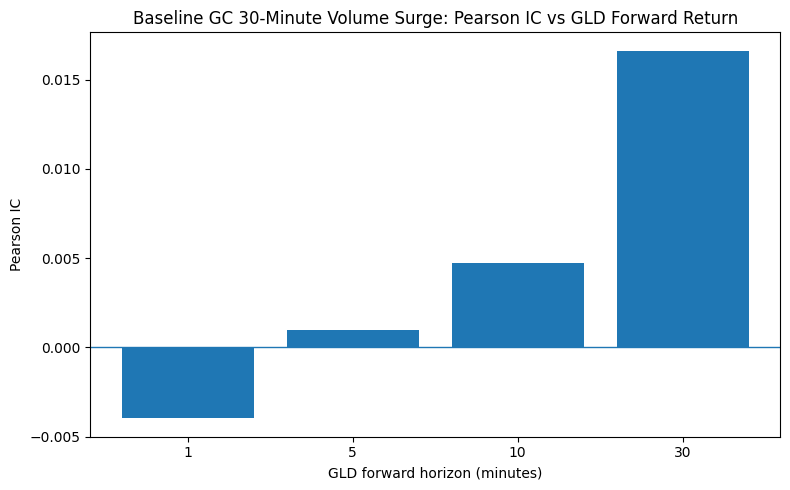

In [20]:
# baseline Pearson IC by horizon
plt.figure(figsize=(8, 5))

plt.bar(
    baseline_ic_table["horizon"].astype(str),
    baseline_ic_table["pearson_ic"],
)

plt.axhline(0, linewidth=1)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Pearson IC")
plt.title("Baseline GC 30-Minute Volume Surge: Pearson IC vs GLD Forward Return")
plt.tight_layout()
plt.show()



**Canonical sampling:** Every IC screen — baseline and candidate — uses the same Close-session (15:00–16:00) horizon-specific sample: drop rows only when the signal or that horizon's GLD target is missing.

#### Candidate evaluation methodology (shared)

**One-axis rule:** Each subsection starts from the baseline specification and varies only the dimension defined in that subsection × GLD forward-return horizon. Settings tested in other subsections do not enter the current search grid.

**Primary ranking metric:** signed Pearson IC = corr(signal, GLD forward return).

**Mathematical definition**

For a continuous feature $X_t$ on the Close-session horizon-specific sample:

$$
\mathrm{IC}_h = \mathrm{Corr}_{\mathrm{Pearson}}\!\left(X_t,\ R_{t,t+h}\right)
$$

Spearman $\mathrm{Corr}$ is the secondary rank-correlation diagnostic / tiebreaker.

Outside B.2, selected-candidate strategy diagnostics use:

$$
\textit{strategy\_return}_t = X_t \cdot R_{t,t+h}
$$

(B.2's trade package uses a separate, local elevated-threshold entry rule — not part of the IC definition.)


**Secondary diagnostic:** Spearman IC. Used for interpretation and as a tiebreaker when Pearson values are genuinely equal or negligibly different. Ranking is not replaced by absolute correlation magnitude.

**Top-two rule:** Rank every legitimate cell in the subsection grid and retain the two strongest complete (specification + horizon) pairs — even if neither beats baseline.

**Baseline comparison:** After selection, compare each candidate to baseline evaluated at the **same** GLD horizon (IC only).

**Selected-candidate metric package:** For the baseline and each retained top-two cell, report avg bps, hit rate, Sharpe, Sortino, n observations / n days, and cumulative PnL. Outside B.2, strategy diagnostics use the continuous construction `strategy_return = signal * forward_return` (no threshold, no always-long). **Only B.2** applies an expanding historical 80th-percentile long-only entry rule. No entry condition lives inside the IC / ranking helpers.



#### Baseline candidate evaluation

Full diagnostic package for the original baseline once: `GC_signal_30`, Close window, 30-minute GLD horizon.
Later subsections reference this numerically instead of re-plotting the baseline.


In [21]:
# baseline IC + continuous strategy diagnostics (signal * forward_return)
baseline_sample = horizon_specific_sample(BASELINE_SIGNAL_COL, 30)
baseline_ic = compute_close_ic(BASELINE_SIGNAL_COL, 30)
baseline_strategy = continuous_strategy_frame(baseline_sample)
baseline_metrics = {
    "candidate": "baseline_30_h30",
    "horizon": 30,
    "pearson_ic": baseline_ic["pearson_ic"],
    "spearman_ic": baseline_ic["spearman_ic"],
    **summarize_strategy_returns(baseline_strategy),
}
pd.DataFrame([baseline_metrics])


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,baseline_30_h30,30,0.016617,-0.00085,0.593722,0.500787,0.699926,1.155564,14609,246


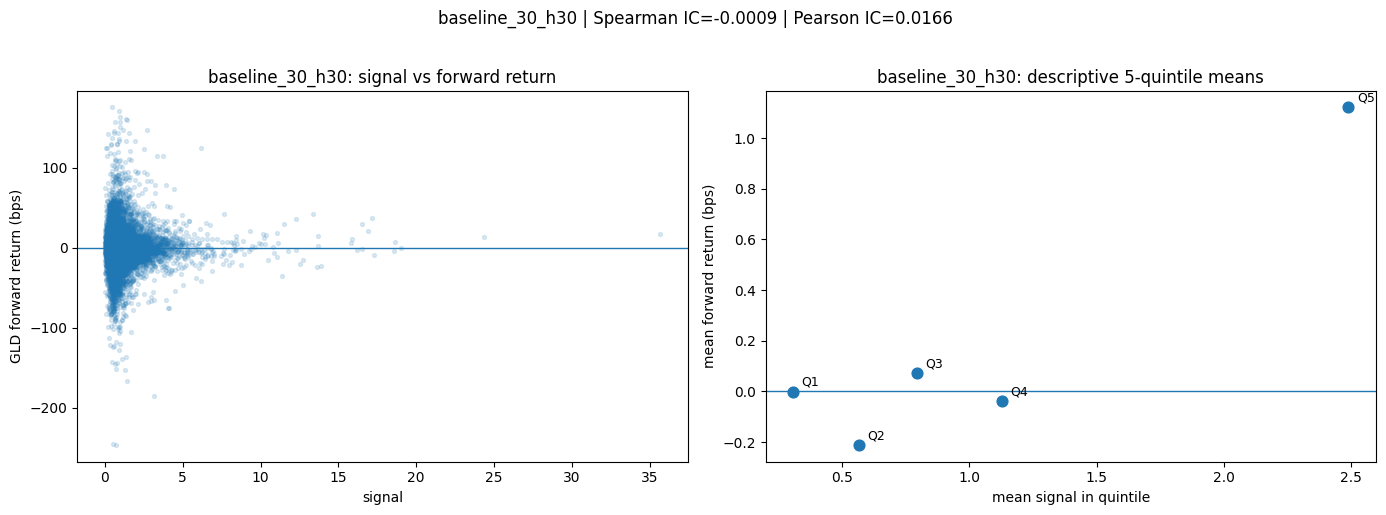

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.306711,-0.000163,2922
1,Q2,0.563290,-0.210544,2922
2,Q3,0.794376,0.072188,2921
3,Q4,1.126442,-0.036384,2922
4,Q5,2.491887,1.120609,2922


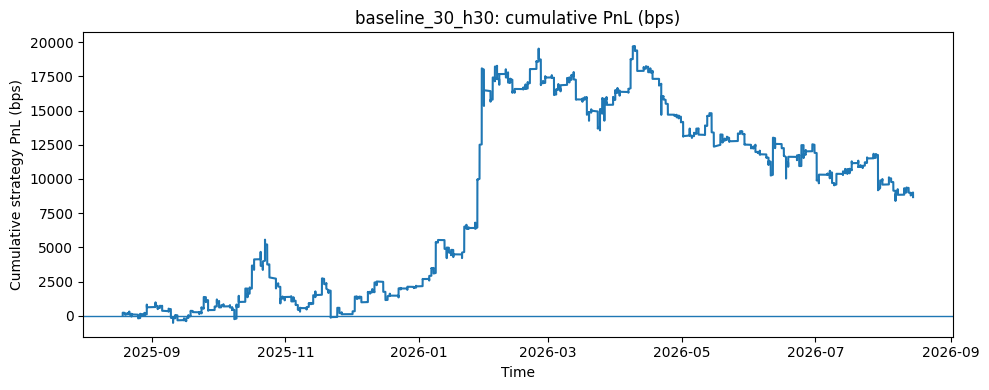

In [22]:
plot_candidate_diagnostics("baseline_30_h30", baseline_sample, baseline_strategy)


- IC measures the linear association between the GC volume-surge signal and subsequent GLD returns. 
- Quintile analysis complements IC by checking whether the relationship is nonlinear or concentrated among unusually large volume surges.


In [23]:
# checking stability across days to prevent one day from dominating the results
daily_ic = []

for h in horizons:
    sample_h = horizon_specific_sample(BASELINE_SIGNAL_COL, h)
    daily = (
        sample_h.groupby("date")
        .apply(
            lambda x: x["signal"].corr(x["fwd_return"]),
            include_groups=False,
        )
        .dropna()
    )

    for date, ic in daily.items():
        daily_ic.append({
            "date": date,
            "horizon": h,
            "IC": ic,
        })

daily_ic = pd.DataFrame(daily_ic)
daily_ic.head(10)


,date,horizon,IC
0,2025-08-18,1,-0.038250
1,2025-08-19,1,-0.037996
2,2025-08-20,1,-0.063325
3,2025-08-21,1,0.125904
4,2025-08-22,1,0.072854
5,2025-08-25,1,0.115898
6,2025-08-26,1,-0.004337
7,2025-08-27,1,0.104320
8,2025-08-28,1,0.183298
9,2025-08-29,1,0.078271


In [24]:
# summary table for above relationship
daily_ic_summary = (
    daily_ic.groupby("horizon")["IC"]
    .agg(["mean", "median", "std", "count"])
)

daily_ic_summary["positive_days_pct"] = (
    daily_ic.groupby("horizon")["IC"]
    .apply(lambda x: (x > 0).mean() * 100)
)

daily_ic_summary

,mean,median,std,count,positive_days_pct
horizon,,,,,
1,0.006083,0.002634,0.146945,246,50.406504
5,0.006913,0.008240,0.159903,246,51.626016
10,0.012897,0.014288,0.187864,246,52.032520
30,0.014882,0.032372,0.217103,246,55.691057


the aim to check whether the baseline effect repeats through time rather than being concentrated in isolated days


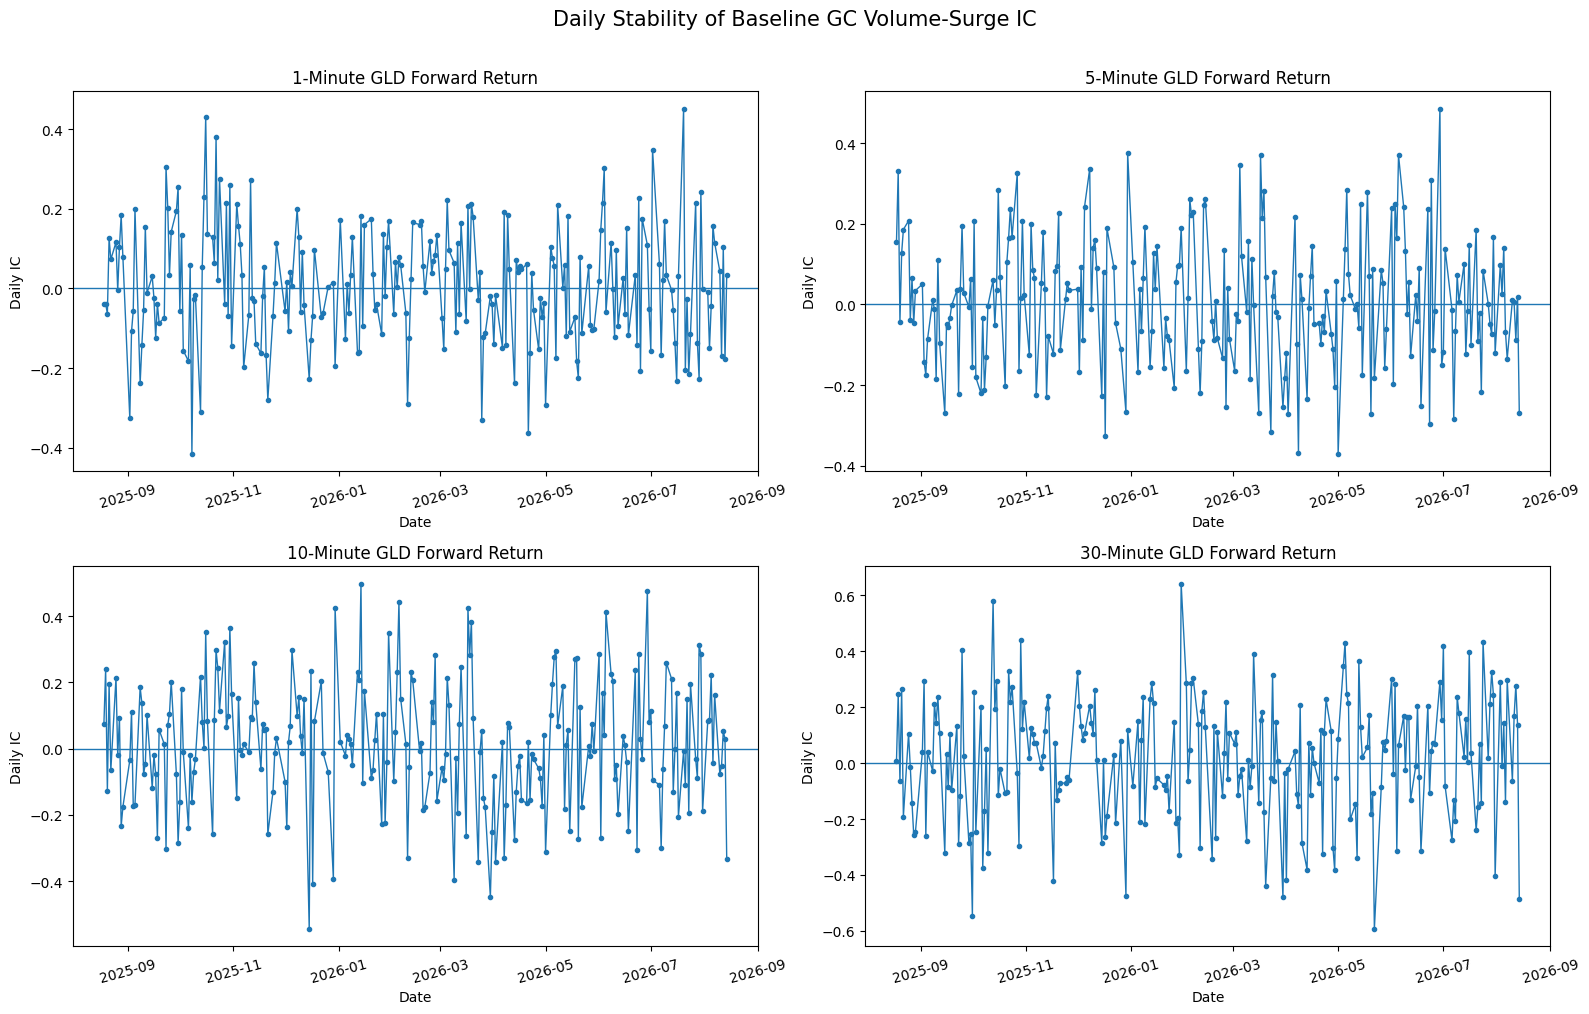

In [25]:
# visualizing the above relationship
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax, h in zip(axes, horizons):

    temp = daily_ic[daily_ic["horizon"] == h].copy()
    temp["date"] = pd.to_datetime(temp["date"])

    ax.plot(
        temp["date"],
        temp["IC"],
        marker="o",
        markersize=3,
        lw=1
    )

    ax.axhline(0, linewidth=1)

    ax.set_xlabel("Date")
    ax.set_ylabel("Daily IC")
    ax.set_title(f"{h}-Minute GLD Forward Return")

    ax.tick_params(axis="x", rotation=15)

plt.suptitle(
    "Daily Stability of Baseline GC Volume-Surge IC",
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

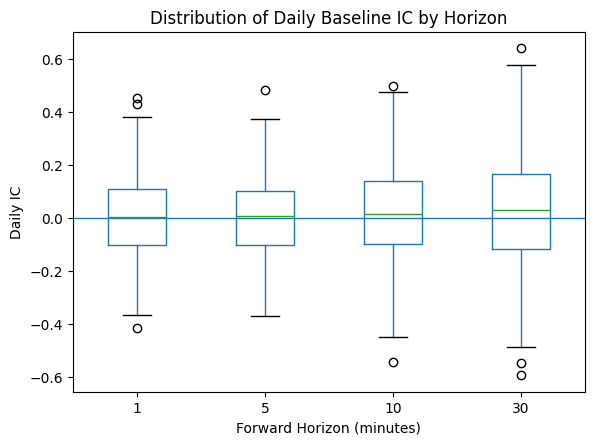

In [26]:
# checking which horizon has the more consistently positive/negative daily relationship
plt.figure(figsize=(8, 5))

daily_ic.boxplot(
    column="IC",
    by="horizon",
    grid=False
)

plt.axhline(0, linewidth=1)

plt.xlabel("Forward Horizon (minutes)")
plt.ylabel("Daily IC")
plt.title("Distribution of Daily Baseline IC by Horizon")
plt.suptitle("")

plt.show()

- if the whole box is mostly above zero, then it's a strongly positive signal
- if it's centered around zero with huge dispersion, then the relationship is unstable (*in our case*)
- if the median is negative but the mean is positive, then we have a too strong positive outliers


In [27]:
# converting the volume signal surge process into a function for future use
def volume_surge_signal(volume, lookback, min_periods=5):
    
    prior_mean = (
        volume
        .shift(1)
        .rolling(
            window=lookback,
            min_periods=min_periods
        )
        .mean()
    )

    raw = volume / prior_mean

    long_run_scale = (
        raw.abs()
        .expanding(min_periods=30)
        .mean()
        .shift(1)
    )

    signal = raw / long_run_scale

    return signal 

### A. Lookback window


#### Method note: lookback windows

Volume lookbacks use pandas row-based rolling (e.g. `rolling(30)` = prior 30 available minute bars), not a strict clock-time window. In the main Close screen (15:00-16:00), missing minutes are rare: about 99.6% of days have all 60 bars, and about 99.96% of consecutive close-session gaps are exactly 1 minute. So the row-based lookback is approximately the intended clock-minute window for these screens.


*The baseline used a 30-minute trailing average. A.1 varies lookback only (5, 10, 15, 30, 60, 90, 120 minutes) while all other baseline settings remain fixed.*

**Method note:** Session/time-of-day is **not** varied here; open-vs-close belongs to a later one-axis section. Volume lookbacks use row-based rolling on available minute bars; in the Close screen this is approximately clock-minute because missing minutes are rare (~99.6% of days have all 60 close bars).


**Mathematical definition**

A.1 varies only the lookback $L \in \{5,10,15,30,60,90,120\}$:

$$
\mu_t^{(L)} = \mathrm{mean}\!\left(V_{t-1},\ldots,V_{t-L}\right)
\quad(\texttt{min\_periods}=5)
$$

$$
\mathrm{Raw}_t^{(L)} = \frac{V_t}{\mu_t^{(L)}},\qquad
S_t^{(L)} = \frac{\mathrm{Raw}_t^{(L)}}{L_t^{(L)}}
$$

where $L_t^{(L)}$ is the same expanding long-run scale of $|\mathrm{Raw}^{(L)}|$ as in the baseline ($\texttt{min\_periods}=30$, past-only).

Held fixed: GC total volume, linear ratio, expanding normalization, Close $[15{:}00,16{:}00)$, horizons $h \in \{1,5,10,30\}$.

Evaluated by $\mathrm{IC}_h = \mathrm{Corr}(S_t^{(L)}, R_{t,t+h})$.


In [28]:
# constructing the signals for the lookback windows
lookbacks = [5, 10, 15, 30, 60, 90, 120]

for lb in lookbacks:
    data[f"GC_signal_{lb}"] = volume_surge_signal(
        data["GC_volume"],
        lookback=lb,
        min_periods=5
    )

In [29]:
# A.1 full screen: lookback × GLD horizon (close session only)
lookback_results = []

for lb in lookbacks:
    for h in horizons:
        stats = compute_close_ic(f"GC_signal_{lb}", h)
        lookback_results.append({
            "lookback": lb,
            "spec_label": f"lookback_{lb}",
            "spec_slug": f"lb{lb}",
            "horizon": h,
            "pearson_ic": stats["pearson_ic"],
            "spearman_ic": stats["spearman_ic"],
            "n_obs": stats["n_obs"],
        })

lookback_results = pd.DataFrame(lookback_results)
lookback_ic_matrix = lookback_results.pivot(
    index="lookback",
    columns="horizon",
    values="pearson_ic",
)
lookback_ic_matrix



horizon,1,5,10,30
lookback,,,,
5,0.002504,-0.002578,-0.003675,0.002113
10,-0.003068,-0.003676,-0.003398,0.006889
15,-0.003963,-0.001776,-0.000388,0.010805
30,-0.003982,0.000964,0.004750,0.016617
60,-0.002630,0.001563,0.004824,0.021547
90,0.000017,0.003196,0.008344,0.029585
120,-0.001169,0.001630,0.006207,0.028562


In [30]:
# A.1 ranked preview (full 28-cell grid)
a1_ranked_preview = lookback_results.sort_values(
    ["pearson_ic", "spearman_ic", "spec_label", "horizon"],
    ascending=[False, False, True, True],
).reset_index(drop=True)
a1_ranked_preview.head(10)


,lookback,spec_label,spec_slug,horizon,pearson_ic,spearman_ic,n_obs
0,90,lookback_90,lb90,30,0.029585,0.014699,14623
1,120,lookback_120,lb120,30,0.028562,0.018539,14624
2,60,lookback_60,lb60,30,0.021547,0.008073,14615
3,30,lookback_30,lb30,30,0.016617,-0.000850,14609
4,15,lookback_15,lb15,30,0.010805,-0.003040,14597
5,90,lookback_90,lb90,10,0.008344,0.005394,14665
6,10,lookback_10,lb10,30,0.006889,-0.000919,14588
7,120,lookback_120,lb120,10,0.006207,0.006225,14666
8,60,lookback_60,lb60,10,0.004824,-0.000196,14657
9,30,lookback_30,lb30,10,0.004750,0.004275,14651


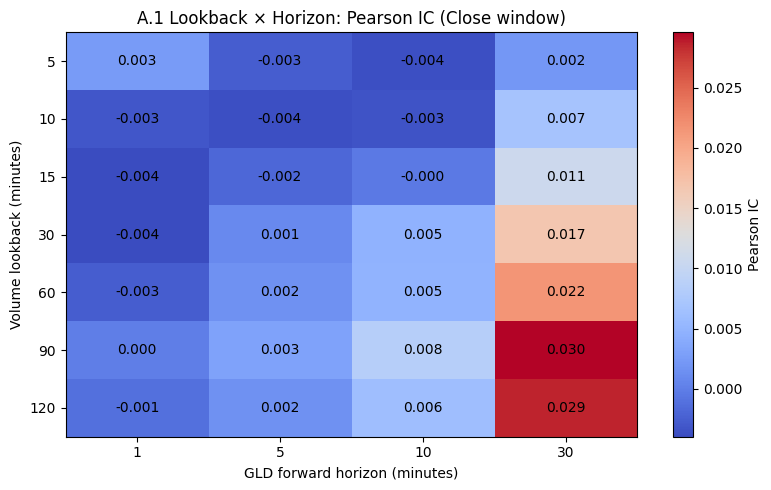

In [31]:
# heatmap: signed Pearson IC across the A.1 search grid
plt.figure(figsize=(8, 5))

plt.imshow(
    lookback_ic_matrix.values,
    aspect="auto",
    cmap="coolwarm",
)

plt.colorbar(label="Pearson IC")
plt.xticks(
    range(len(lookback_ic_matrix.columns)),
    lookback_ic_matrix.columns,
)
plt.yticks(
    range(len(lookback_ic_matrix.index)),
    lookback_ic_matrix.index,
)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Volume lookback (minutes)")
plt.title("A.1 Lookback × Horizon: Pearson IC (Close window)")

for i in range(lookback_ic_matrix.shape[0]):
    for j in range(lookback_ic_matrix.shape[1]):
        value = lookback_ic_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
            )

plt.tight_layout()
plt.show()



**Evaluation note:** Open vs close session comparison is **not** part of the A.1 search grid. Session/time-of-day is a separate one-axis dimension reserved for a later section. A.1 ranks only lookback × GLD horizon in the fixed baseline close window (15:00–16:00).


#### A.1 top-two selection

Rank all 28 legitimate lookback×horizon cells by signed Pearson IC. The two strongest complete specifications are packaged below regardless of baseline comparison.


Top two A.1 candidates (signed Pearson IC ranking across all 28 cells):


,candidate_id,spec_label,horizon,pearson_ic,spearman_ic,baseline_equivalent,n_obs
0,A1_lb90_h30,lookback_90,30,0.029585,0.014699,False,14623
1,A1_lb120_h30,lookback_120,30,0.028562,0.018539,False,14624



=== Candidate 1: A1_lb90_h30 ===
Specification: lookback_90 @ 30m GLD horizon


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,A1_lb90_h30,30,0.029585,0.014699,0.82031,0.500513,0.992375,1.675479,14623,248


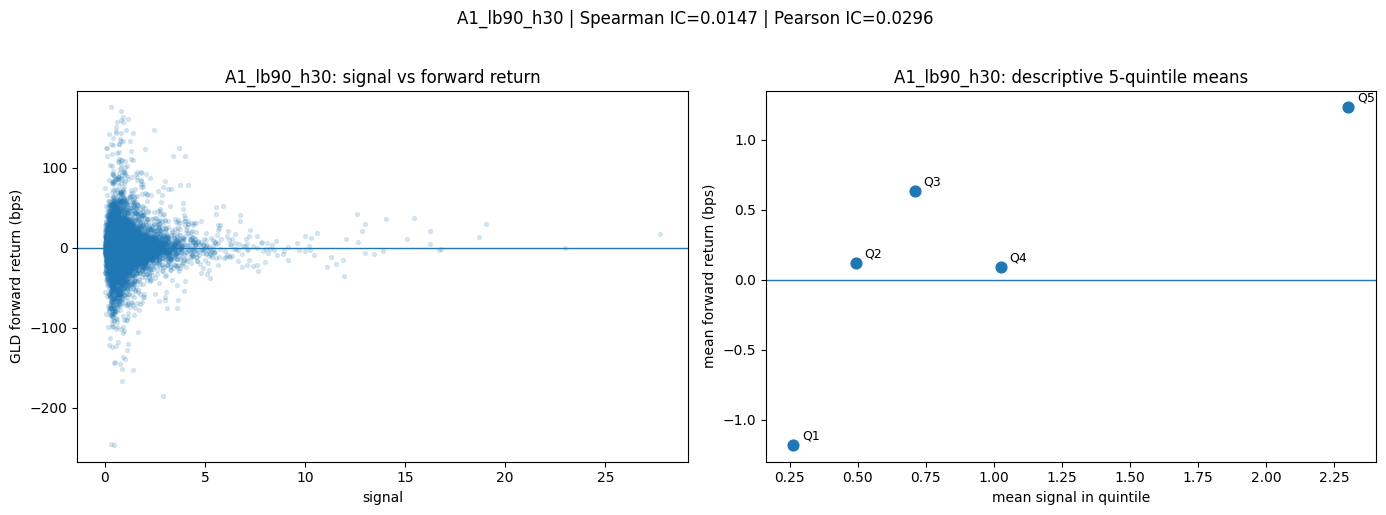

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.264281,-1.179165,2925
1,Q2,0.494348,0.122409,2924
2,Q3,0.710425,0.632286,2925
3,Q4,1.024342,0.088734,2924
4,Q5,2.301420,1.231762,2925


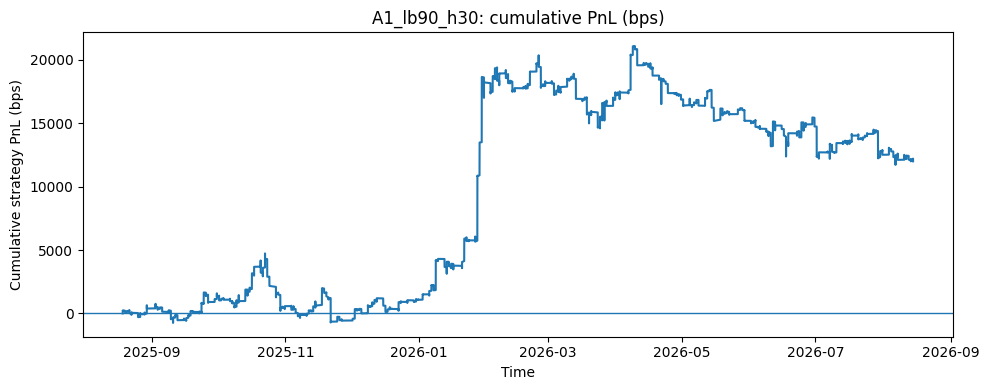


=== Candidate 2: A1_lb120_h30 ===
Specification: lookback_120 @ 30m GLD horizon


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,A1_lb120_h30,30,0.028562,0.018539,0.68899,0.500547,0.932852,1.534651,14624,248


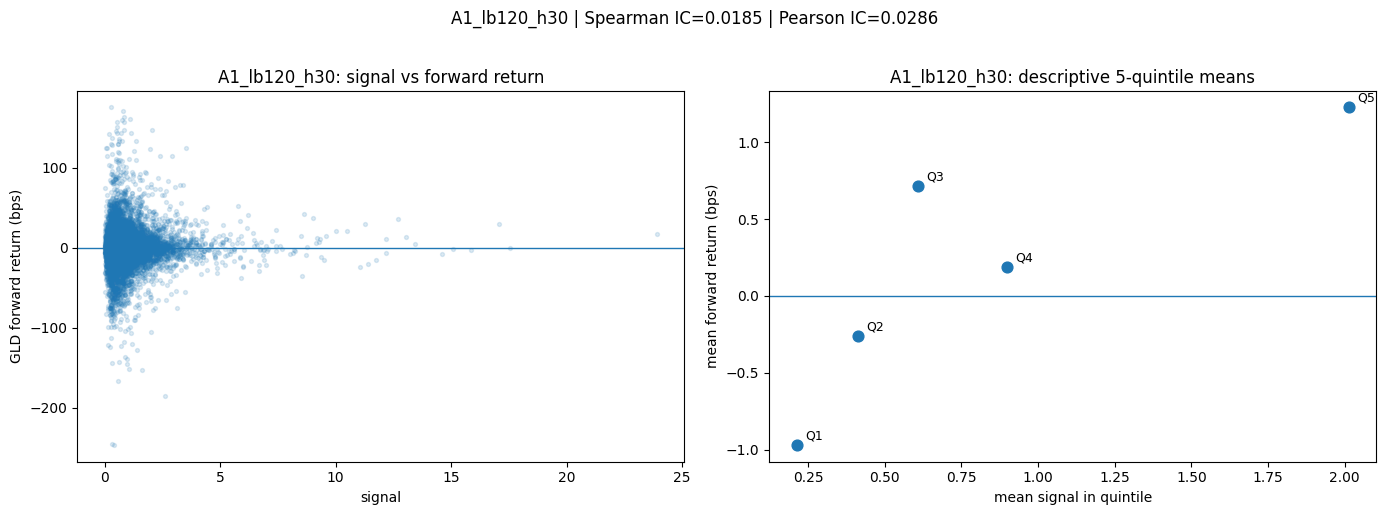

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.212444,-0.967747,2925
1,Q2,0.413161,-0.260446,2925
2,Q3,0.608250,0.712330,2924
3,Q4,0.897612,0.187956,2925
4,Q5,2.013185,1.225358,2925


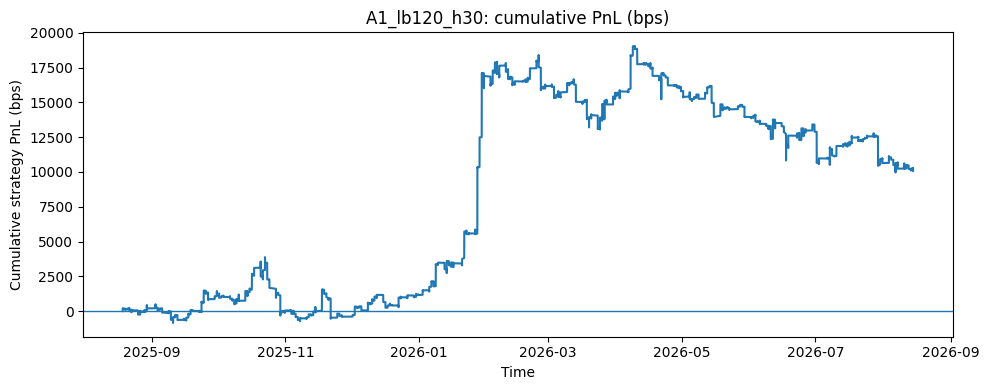


=== A1 baseline comparison (same horizon) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,A1_lb90_h30,30,False,0.029585,0.014699,0.016617,-0.00085,0.012968,candidate beats baseline
1,A1_lb120_h30,30,False,0.028562,0.018539,0.016617,-0.00085,0.011945,candidate beats baseline


In [32]:
# A.1 top-two selection (28-cell grid)
a1_top_two = rank_top_two(lookback_results)

a1_signal_map = {f"lookback_{lb}": f"GC_signal_{lb}" for lb in lookbacks}

a1_top_two_display = a1_top_two.copy()
a1_top_two_display["candidate_id"] = a1_top_two_display.apply(
    lambda r: f"A1_{r['spec_slug']}_h{int(r['horizon'])}", axis=1
)
a1_top_two_display["baseline_equivalent"] = a1_top_two_display["spec_label"].eq("lookback_30")

print("Top two A.1 candidates (signed Pearson IC ranking across all 28 cells):")
display(
    a1_top_two_display[[
        "candidate_id", "spec_label", "horizon", "pearson_ic", "spearman_ic",
        "baseline_equivalent", "n_obs",
    ]]
)

# top-two diagnostics: IC + selected-candidate metric package + plots
a1_stored = {}
a1_compare_rows = []

for rank, row in a1_top_two.iterrows():
    spec = row["spec_label"]
    horizon = int(row["horizon"])
    signal_col = a1_signal_map[spec]
    cid = f"A1_{row['spec_slug']}_h{horizon}"
    is_base = spec == "lookback_30"

    print(f"\n=== Candidate {rank + 1}: {cid} ===")
    print(f"Specification: {spec} @ {horizon}m GLD horizon")
    if is_base:
        print("Note: baseline-equivalent construction within this subsection.")

    sample = horizon_specific_sample(signal_col, horizon)
    ic = compute_close_ic(signal_col, horizon)
    strategy = continuous_strategy_frame(sample)
    metrics = {
        "candidate": cid,
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        **summarize_strategy_returns(strategy),
    }
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, strategy)

    a1_compare_rows.append(
        baseline_comparison_row(cid, signal_col, horizon, baseline_equivalent=is_base)
    )
    a1_stored[cid] = (metrics, sample, strategy)

a1_compare = pd.DataFrame(a1_compare_rows)
print(f"\n=== A1 baseline comparison (same horizon) ===")
display(a1_compare)



#### A.1 assessment

**Signal screen:** Longer lookbacks (especially 90m and 120m) dominate the close-window Pearson IC grid at the 30-minute GLD horizon (~0.030 / ~0.029 vs baseline 30m lookback ~0.017 (Pearson IC 0.016617)). Ranking across all 28 lookback×horizon cells may also elevate other horizon/specification pairs if their signed Pearson IC is higher.

**Within-subsection ranking:** 90m and 120m lookbacks @ 30m are the top-two Pearson IC cells in the 28-cell grid.

**Baseline comparison:** Both retained candidates beat baseline Pearson IC at 30m. No baseline-equivalent lookback_30 cell appears in the top two.

**Decision:** Record both top-two A.1 candidates for later joint testing. Session/time-of-day is intentionally not part of this grid (deferred to a later one-axis section).



#### A.2 Expanding vs rolling normalization

Hold the baseline construction fixed and ask only whether the normalization should be expanding or rolling.

Fixed pieces:
- volume lookback = 30 minutes
- rolling volume mean uses min_periods = 5
- normalization uses min_periods = 30
- session = Close (15:00-16:00)
- horizons = 1 / 5 / 10 / 30 minutes

Raw ratio:

`raw = GC volume this minute / mean GC volume over the prior 30 minutes`

Then:
- expanding: divide by the mean of all past abs(raw)
- rolling: divide by the mean of only the previous K abs(raw) values

Rolling windows used: 60, 390, 1950
- 60 = about 1 hour (short)
- 390 = about one cash equity day (medium)
- 1950 = about five cash equity days (longer)


**Mathematical definition**

Hold the 30-bar raw surge fixed:

$$
\mathrm{Raw}_t = \frac{V_t}{\mu_t^{(30)}}
$$

Then only the scale in the denominator changes:

$$
S_t^{\mathrm{exp}} = \frac{\mathrm{Raw}_t}{\mathrm{mean}(|\mathrm{Raw}_s|)_{s<t}}
\quad(\texttt{expanding},\ \texttt{min\_periods}=30)
$$

$$
S_t^{\mathrm{roll}(K)} = \frac{\mathrm{Raw}_t}{\mathrm{mean}(|\mathrm{Raw}_s|)_{s \in [t-K,\,t-1]}}
\quad(K \in \{60,390,1950\},\ \texttt{min\_periods}=30)
$$

Held fixed: $L=30$, linear GC volume ratio, Close window, horizons. Evaluated by $\mathrm{IC}_h = \mathrm{Corr}(S_t^{\cdot}, R_{t,t+h})$.


In [33]:
# fixed 30-minute raw ratio (same construction as baseline)
prior_mean_30 = (
    data["GC_volume"]
    .shift(1)
    .rolling(window=30, min_periods=5)
    .mean()
)

raw_30 = data["GC_volume"] / prior_mean_30

# expanding normalization (baseline style)
data["GC_signal_expanding"] = raw_30 / (
    raw_30.abs()
    .expanding(min_periods=30)
    .mean()
    .shift(1)
)

# rolling normalization for a small set of windows
rolling_windows = [60, 390, 1950]

for k in rolling_windows:
    data[f"GC_signal_rollnorm_{k}"] = raw_30 / (
        raw_30.abs()
        .rolling(window=k, min_periods=30)
        .mean()
        .shift(1)
    )

In [34]:
# close-window IC: expanding vs rolling normalization (normalization × horizon only)
norm_results = []

norm_specs = [
    ("expanding", "GC_signal_expanding", "expanding"),
    ("rollnorm_60", "GC_signal_rollnorm_60", "rollnorm_60"),
    ("rollnorm_390", "GC_signal_rollnorm_390", "rollnorm_390"),
    ("rollnorm_1950", "GC_signal_rollnorm_1950", "rollnorm_1950"),
]

for label, col, slug in norm_specs:
    for h in horizons:
        stats = compute_close_ic(col, h)
        norm_results.append({
            "spec_label": label,
            "spec_slug": slug,
            "horizon": h,
            "pearson_ic": stats["pearson_ic"],
            "spearman_ic": stats["spearman_ic"],
            "n_obs": stats["n_obs"],
        })

norm_results = pd.DataFrame(norm_results)

norm_ic_matrix = norm_results.pivot(
    index="spec_label",
    columns="horizon",
    values="pearson_ic",
)

norm_ic_matrix



horizon,1,5,10,30
spec_label,,,,
expanding,-0.003982,0.000964,0.004750,0.016617
rollnorm_1950,-0.003672,0.001158,0.005039,0.017248
rollnorm_390,-0.004419,0.000090,0.003938,0.013870
rollnorm_60,-0.006443,-0.003475,-0.001318,0.007401


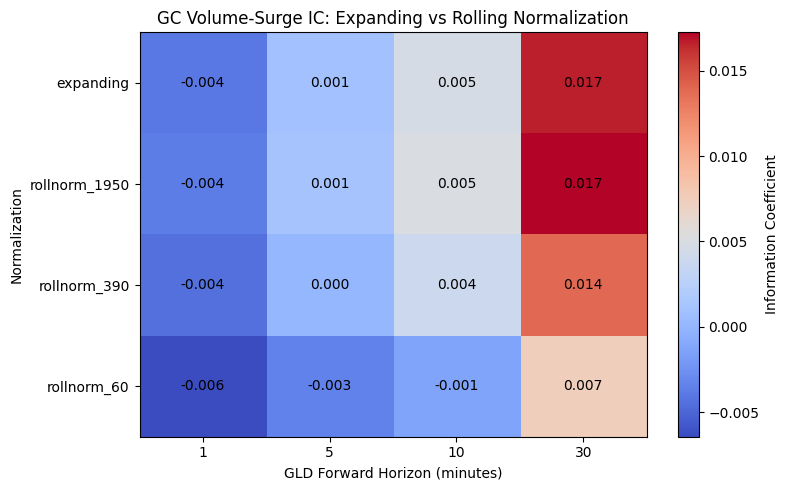

In [35]:
# heatmap of expanding vs rolling IC in the close window
plt.figure(figsize=(8, 5))

plt.imshow(
    norm_ic_matrix.values,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Information Coefficient")

plt.xticks(
    range(len(norm_ic_matrix.columns)),
    norm_ic_matrix.columns
)

plt.yticks(
    range(len(norm_ic_matrix.index)),
    norm_ic_matrix.index
)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Normalization")
plt.title("GC Volume-Surge IC: Expanding vs Rolling Normalization")

for i in range(len(norm_ic_matrix.index)):
    for j in range(len(norm_ic_matrix.columns)):
        plt.text(
            j,
            i,
            f"{norm_ic_matrix.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [36]:
# consistency check: A.2 expanding should match A.1 lookback=30 in the close window
a1_close_30 = (
    lookback_results[lookback_results["lookback"] == 30]
    [["horizon", "pearson_ic"]]
    .rename(columns={"pearson_ic": "A1_IC"})
)

a2_expanding = (
    norm_results[norm_results["spec_label"] == "expanding"]
    [["horizon", "pearson_ic"]]
    .rename(columns={"pearson_ic": "A2_expanding_IC"})
)

consistency = a1_close_30.merge(a2_expanding, on="horizon")
consistency["difference"] = (
    consistency["A2_expanding_IC"] - consistency["A1_IC"]
)

consistency


,horizon,A1_IC,A2_expanding_IC,difference
0,1,-0.003982,-0.003982,0.0
1,5,0.000964,0.000964,0.0
2,10,0.004750,0.004750,0.0
3,30,0.016617,0.016617,0.0


#### A.2 top-two selection

Rank all 16 normalization×horizon cells. Expanding normalization is baseline-equivalent and remains eligible.


Top two A.2 candidates (16-cell normalization × horizon grid):


,candidate_id,spec_label,horizon,pearson_ic,spearman_ic,baseline_equivalent,n_obs
0,A2_rollnorm_1950_h30,rollnorm_1950,30,0.017248,-0.001212,False,14609
1,A2_expanding_h30,expanding,30,0.016617,-0.000850,True,14609



=== Candidate 1: A2_rollnorm_1950_h30 ===
Specification: rollnorm_1950 @ 30m GLD horizon


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,A2_rollnorm_1950_h30,30,0.017248,-0.001212,0.605936,0.500787,0.713643,1.194504,14609,246


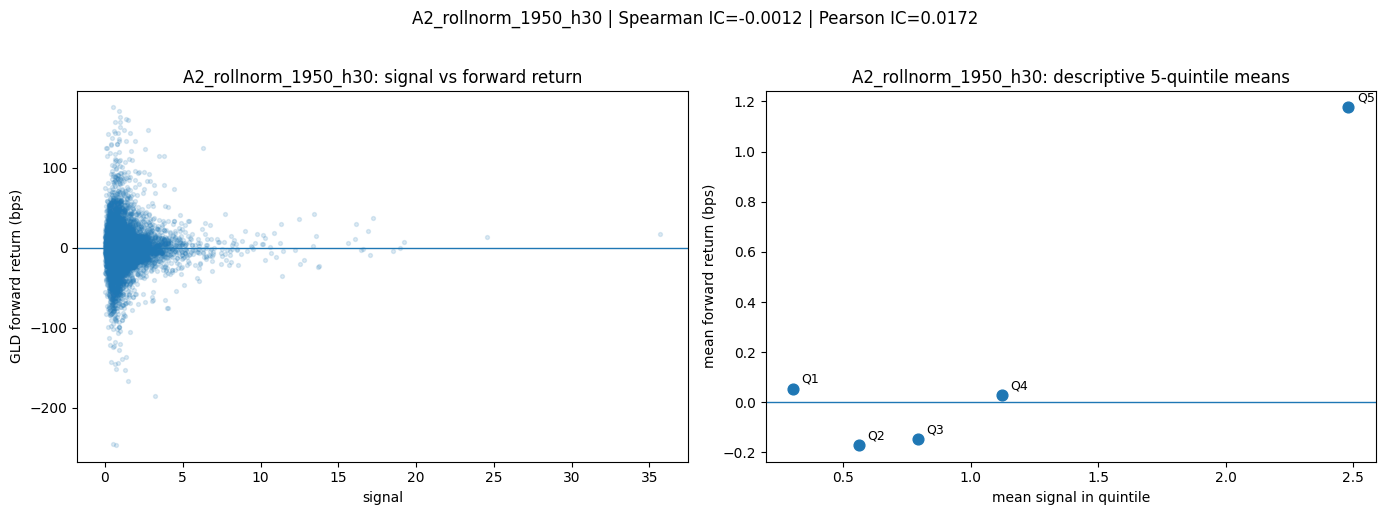

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.304051,0.055207,2922
1,Q2,0.560452,-0.169546,2922
2,Q3,0.791272,-0.146242,2921
3,Q4,1.122940,0.030092,2922
4,Q5,2.480531,1.176120,2922


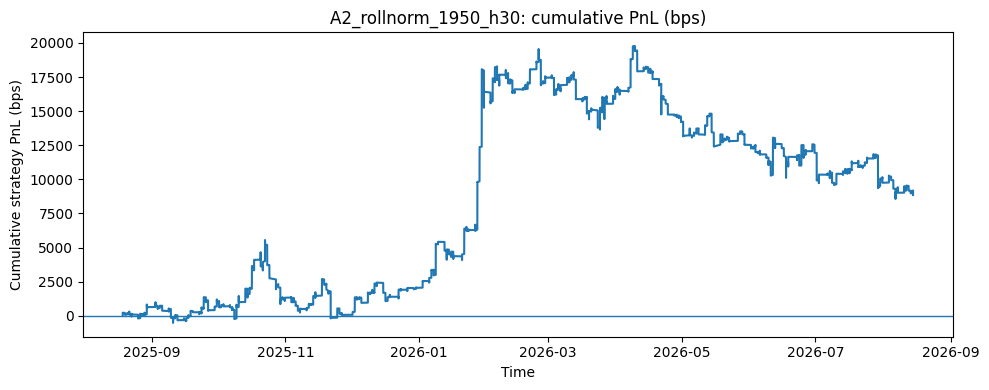


=== Candidate 2: A2_expanding_h30 ===
Specification: expanding @ 30m GLD horizon
Note: baseline-equivalent construction within this subsection.


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,A2_expanding_h30,30,0.016617,-0.00085,0.593722,0.500787,0.699926,1.155564,14609,246


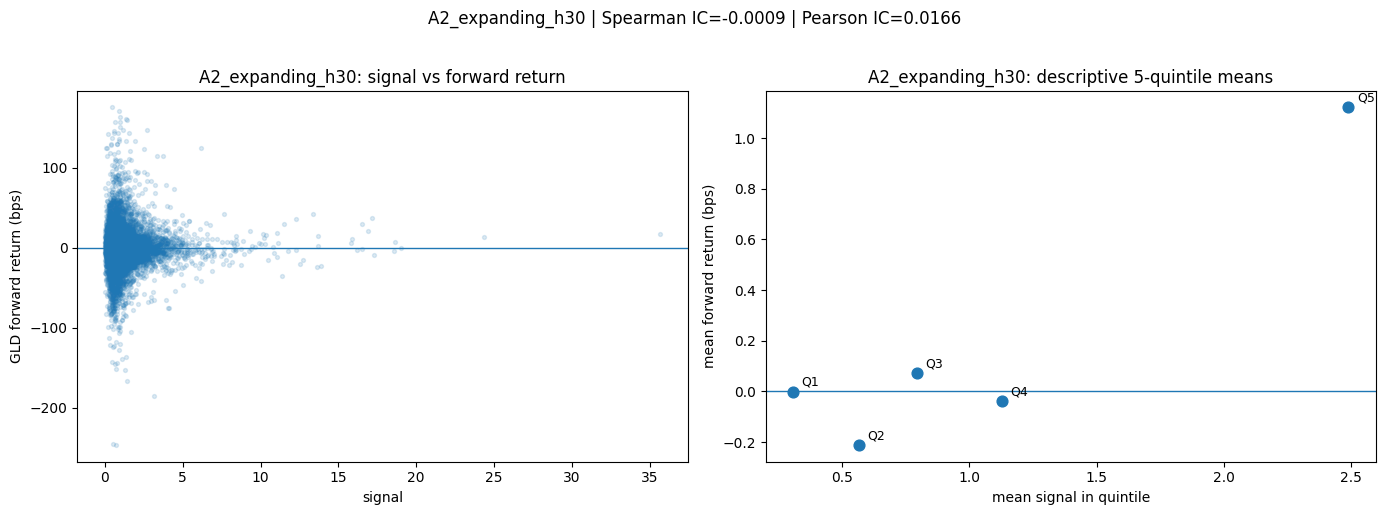

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.306711,-0.000163,2922
1,Q2,0.563290,-0.210544,2922
2,Q3,0.794376,0.072188,2921
3,Q4,1.126442,-0.036384,2922
4,Q5,2.491887,1.120609,2922


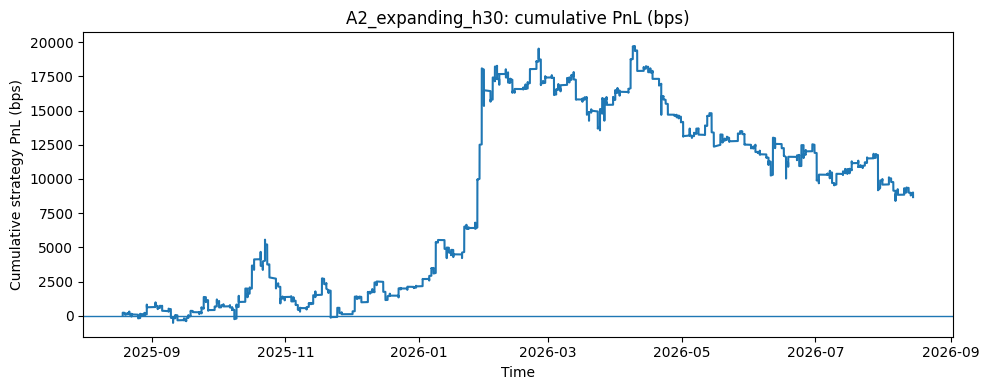


=== A2 baseline comparison (same horizon) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,A2_rollnorm_1950_h30,30,False,0.017248,-0.001212,0.016617,-0.00085,0.000631,candidate beats baseline
1,A2_expanding_h30,30,True,0.016617,-0.000850,0.016617,-0.00085,0.000000,baseline-equivalent / tied


In [37]:
# A.2 full screen already stored in norm_results
a2_top_two = rank_top_two(norm_results)

a2_signal_map = {
    "expanding": "GC_signal_expanding",
    "rollnorm_60": "GC_signal_rollnorm_60",
    "rollnorm_390": "GC_signal_rollnorm_390",
    "rollnorm_1950": "GC_signal_rollnorm_1950",
}

a2_top_two_display = a2_top_two.copy()
a2_top_two_display["candidate_id"] = a2_top_two_display.apply(
    lambda r: f"A2_{r['spec_slug']}_h{int(r['horizon'])}", axis=1
)
a2_top_two_display["baseline_equivalent"] = a2_top_two_display["spec_label"].eq("expanding")

print("Top two A.2 candidates (16-cell normalization × horizon grid):")
display(
    a2_top_two_display[[
        "candidate_id", "spec_label", "horizon", "pearson_ic", "spearman_ic",
        "baseline_equivalent", "n_obs",
    ]]
)

# top-two diagnostics: IC + selected-candidate metric package + plots
a2_stored = {}
a2_compare_rows = []

for rank, row in a2_top_two.iterrows():
    spec = row["spec_label"]
    horizon = int(row["horizon"])
    signal_col = a2_signal_map[spec]
    cid = f"A2_{row['spec_slug']}_h{horizon}"
    is_base = spec == "expanding"

    print(f"\n=== Candidate {rank + 1}: {cid} ===")
    print(f"Specification: {spec} @ {horizon}m GLD horizon")
    if is_base:
        print("Note: baseline-equivalent construction within this subsection.")

    sample = horizon_specific_sample(signal_col, horizon)
    ic = compute_close_ic(signal_col, horizon)
    strategy = continuous_strategy_frame(sample)
    metrics = {
        "candidate": cid,
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        **summarize_strategy_returns(strategy),
    }
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, strategy)

    a2_compare_rows.append(
        baseline_comparison_row(cid, signal_col, horizon, baseline_equivalent=is_base)
    )
    a2_stored[cid] = (metrics, sample, strategy)

a2_compare = pd.DataFrame(a2_compare_rows)
print(f"\n=== A2 baseline comparison (same horizon) ===")
display(a2_compare)



#### A.2 assessment

**Signal screen:** Short rolling norms are weaker. Rolling-1950 is only slightly above expanding on Pearson IC at the 30m GLD horizon (0.017248 vs 0.016617).

**Within-subsection ranking:** Rolling-1950 @ 30m and expanding @ 30m are the top-two Pearson IC cells in the 16-cell grid.

**Baseline comparison:** Rolling-1950 @ 30m beats baseline on Pearson IC at 30m; expanding @ 30m is baseline-equivalent / tied. Registry inclusion does not require beating baseline.

**Decision:** Record both top-two A.2 normalization×horizon cells for later joint testing.


### Section A - Conclusion

**Question:** Is the 30-minute lookback structurally preferred, or an artifact of the initial baseline? Does second-stage normalization materially change the signal?

**What each subsection established**
- **A.1 (lookback only):** The legitimate grid is 7 lookbacks × 4 GLD horizons in the fixed close session. Longer lookbacks (90m / 120m) clearly beat the 30m baseline at the 30-minute GLD horizon on Pearson IC (~0.030 / ~0.029 vs ~0.017). The top-two selection retains the strongest complete lookback+horizon pairs from that 28-cell screen regardless of baseline comparison.
- **A.2 (normalization only):** With lookback fixed at 30 minutes, rolling-1950 is only slightly above expanding on Pearson IC at 30m (0.017248 vs 0.016617). Short rolling norms are weaker.

**Decision / takeaway:** Under one-axis evaluation, **30-minute lookback is not structurally preferred** on the close 30m screen — longer lookbacks dominate. Normalization choice is secondary: rolling-1950 is a modest incremental alternative to expanding. Both subsections retain two strongest cells each for later consolidation after A–E. Session/time-of-day was not varied here.



### B. Volume ratio construction

*Which definition of unusual volume best predicts future GLD returns under fair evaluation?*

Controls held fixed in this section:
- local volume lookback = 30 minutes
- Close session = 15:00-16:00
- expanding normalization
- existing min_periods settings

We change the volume construction only. All four GLD horizons (1/5/10/30) are still evaluated.
Promising lookbacks from Section A are not re-swept here; they can be combined with B winners later.


#### B.1 Mean vs median

Compare current volume / prior 30-minute mean against current volume / prior 30-minute median.
Same expanding normalization afterward.

*Change is only made to rolling mean, making it rolling median, while expanding mean stays the same.*


**Mathematical definition**

With lookback $L=30$ (past-only):

$$
\mathrm{Raw}_t^{\mathrm{mean}} = \frac{V_t}{\mathrm{mean}(V_{t-1},\ldots,V_{t-L})}
$$

$$
\mathrm{Raw}_t^{\mathrm{median}} = \frac{V_t}{\mathrm{median}(V_{t-1},\ldots,V_{t-L})}
$$

Then the same expanding scale:

$$
S_t^{\cdot} = \frac{\mathrm{Raw}_t^{\cdot}}{\mathrm{mean}(|\mathrm{Raw}_s^{\cdot}|)_{s<t}}
$$

Only the local denominator (mean vs median) changes; expanding normalization remains a mean of absolute raw values. Evaluated by $\mathrm{IC}_h$.


In [38]:
# mean vs median raw ratios (30-minute lookback)
gc_prior_mean_30 = (
    data["GC_volume"]
    .shift(1)
    .rolling(window=30, min_periods=5)
    .mean()
)

gc_prior_median_30 = (
    data["GC_volume"]
    .shift(1)
    .rolling(window=30, min_periods=5)
    .median()
)

raw_mean = data["GC_volume"] / gc_prior_mean_30
raw_median = data["GC_volume"] / gc_prior_median_30

data["GC_signal_mean"] = raw_mean / (
    raw_mean.abs().expanding(min_periods=30).mean().shift(1)
)

data["GC_signal_median"] = raw_median / (
    raw_median.abs().expanding(min_periods=30).mean().shift(1)
)

In [39]:
# B.1 full screen: mean vs median denominator × horizon
b1_results = []

for label, col, slug in [
    ("mean", "GC_signal_mean", "mean"),
    ("median", "GC_signal_median", "median"),
]:
    for h in horizons:
        stats = compute_close_ic(col, h)
        b1_results.append({
            "spec_label": label,
            "spec_slug": slug,
            "horizon": h,
            "pearson_ic": stats["pearson_ic"],
            "spearman_ic": stats["spearman_ic"],
            "n_obs": stats["n_obs"],
        })

b1_results = pd.DataFrame(b1_results)
b1_ic = b1_results.pivot(index="spec_label", columns="horizon", values="pearson_ic")
b1_ic



horizon,1,5,10,30
spec_label,,,,
mean,-0.003982,0.000964,0.004750,0.016617
median,-0.003904,0.002552,0.004989,0.017526


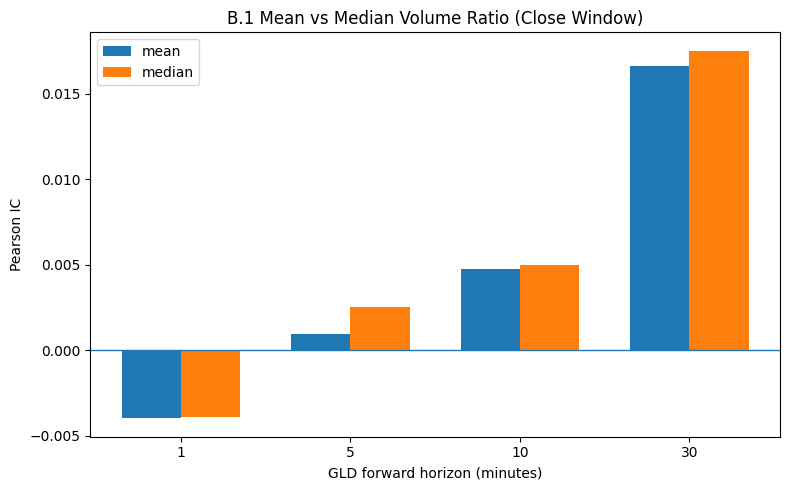

In [40]:
# simple bar comparison at each horizon (Pearson IC)
x = np.arange(len(horizons))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    b1_ic.loc["mean", horizons].values,
    width,
    label="mean",
)
plt.bar(
    x + width / 2,
    b1_ic.loc["median", horizons].values,
    width,
    label="median",
)

plt.axhline(0, linewidth=1)
plt.xticks(x, horizons)
plt.xlabel("GLD forward horizon (minutes)")
plt.ylabel("Pearson IC")
plt.title("B.1 Mean vs Median Volume Ratio (Close Window)")
plt.legend()
plt.tight_layout()
plt.show()


#### B.1 top-two selection


,spec_label,spec_slug,horizon,pearson_ic,spearman_ic,n_obs,candidate_id,baseline_equivalent
0,median,median,30,0.017526,0.010506,14609,B1_median_h30,False
1,mean,mean,30,0.016617,-0.000850,14609,B1_mean_h30,True



=== Candidate 1: B1_median_h30 ===
Specification: median @ 30m GLD horizon


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,B1_median_h30,30,0.017526,0.010506,0.659652,0.500787,0.787332,1.268299,14609,246


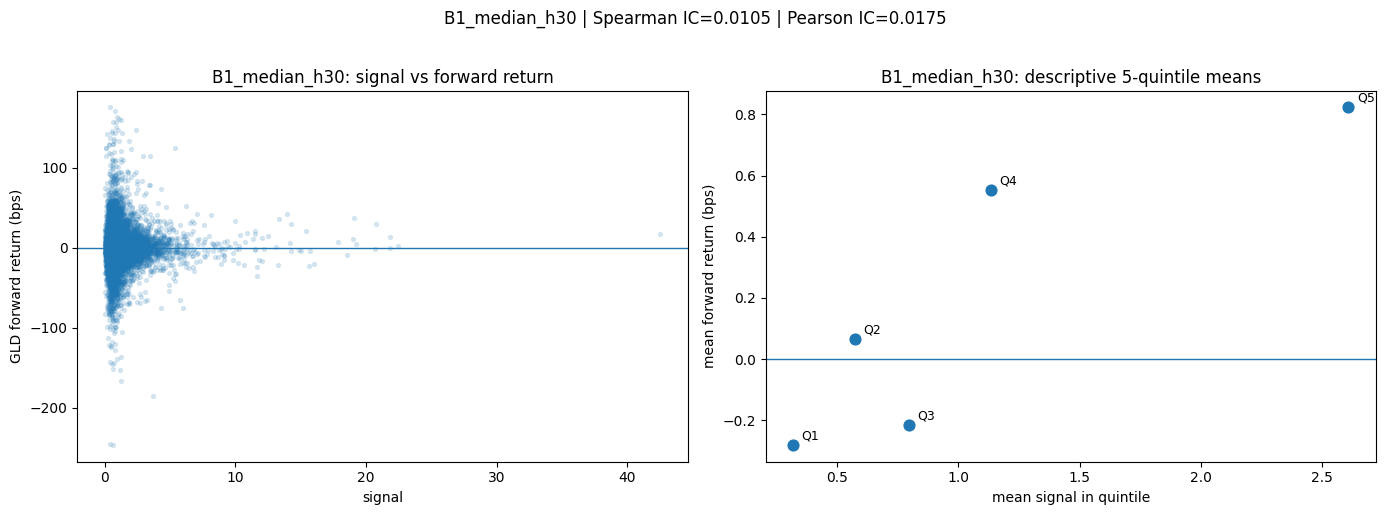

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.318772,-0.279881,2922
1,Q2,0.572284,0.065443,2922
2,Q3,0.796213,-0.214312,2921
3,Q4,1.132639,0.551912,2922
4,Q5,2.609427,0.822446,2922


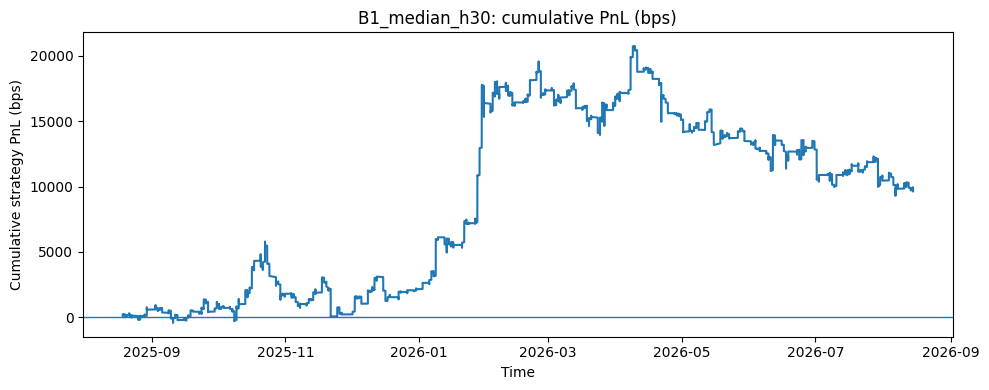


=== Candidate 2: B1_mean_h30 ===
Specification: mean @ 30m GLD horizon
Note: baseline-equivalent construction within this subsection.


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,B1_mean_h30,30,0.016617,-0.00085,0.593722,0.500787,0.699926,1.155564,14609,246


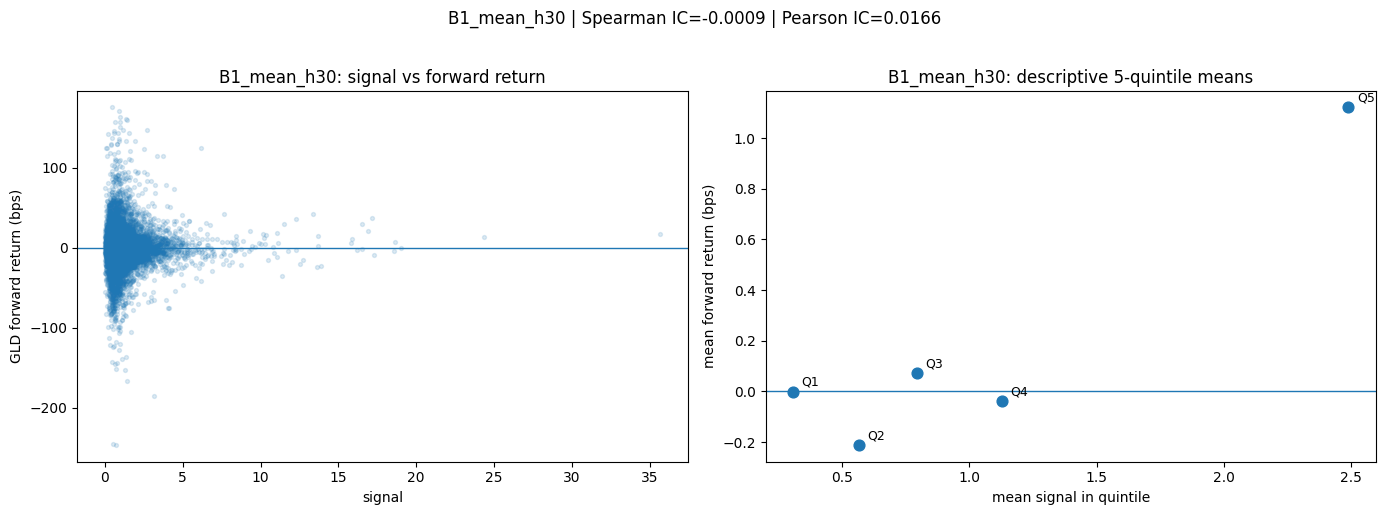

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.306711,-0.000163,2922
1,Q2,0.563290,-0.210544,2922
2,Q3,0.794376,0.072188,2921
3,Q4,1.126442,-0.036384,2922
4,Q5,2.491887,1.120609,2922


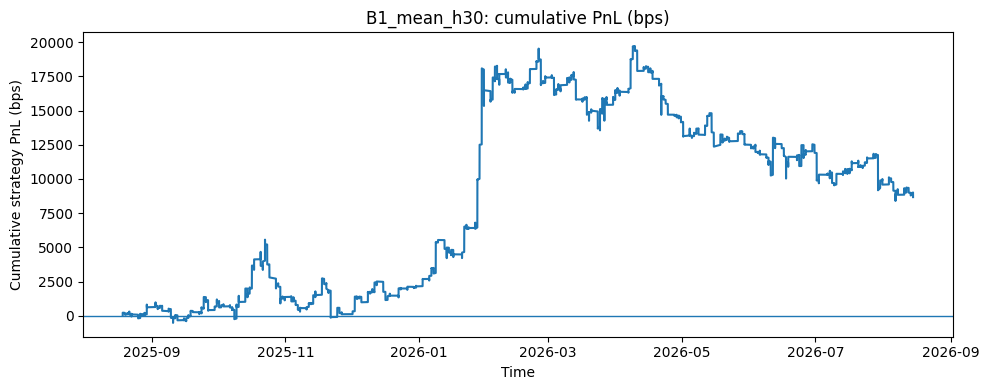


=== B1 baseline comparison (same horizon) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,B1_median_h30,30,False,0.017526,0.010506,0.016617,-0.00085,0.000909,candidate beats baseline
1,B1_mean_h30,30,True,0.016617,-0.000850,0.016617,-0.00085,0.000000,baseline-equivalent / tied


In [41]:
b1_top_two = rank_top_two(b1_results)
b1_signal_map = {"mean": "GC_signal_mean", "median": "GC_signal_median"}

b1_top_two_display = b1_top_two.copy()
b1_top_two_display["candidate_id"] = b1_top_two_display.apply(
    lambda r: f"B1_{r['spec_slug']}_h{int(r['horizon'])}", axis=1
)
b1_top_two_display["baseline_equivalent"] = b1_top_two_display["spec_label"].eq("mean")

display(b1_top_two_display)
# top-two diagnostics: IC + selected-candidate metric package + plots
b1_stored = {}
b1_compare_rows = []

for rank, row in b1_top_two.iterrows():
    spec = row["spec_label"]
    horizon = int(row["horizon"])
    signal_col = b1_signal_map[spec]
    cid = f"B1_{row['spec_slug']}_h{horizon}"
    is_base = spec == "mean"

    print(f"\n=== Candidate {rank + 1}: {cid} ===")
    print(f"Specification: {spec} @ {horizon}m GLD horizon")
    if is_base:
        print("Note: baseline-equivalent construction within this subsection.")

    sample = horizon_specific_sample(signal_col, horizon)
    ic = compute_close_ic(signal_col, horizon)
    strategy = continuous_strategy_frame(sample)
    metrics = {
        "candidate": cid,
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        **summarize_strategy_returns(strategy),
    }
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, strategy)

    b1_compare_rows.append(
        baseline_comparison_row(cid, signal_col, horizon, baseline_equivalent=is_base)
    )
    b1_stored[cid] = (metrics, sample, strategy)

b1_compare = pd.DataFrame(b1_compare_rows)
print(f"\n=== B1 baseline comparison (same horizon) ===")
display(b1_compare)



#### B.1 assessment

**Signal screen:** Median is slightly above mean at every horizon, but the gap is small (30m Pearson IC ~0.0175 vs ~0.0166).

**Within-subsection ranking:** Median @ 30m and mean @ 30m are the top-two Pearson IC cells in the 8-cell grid.

**Baseline comparison:** Median @ 30m beats baseline on Pearson IC at 30m; mean @ 30m is baseline-equivalent / tied.

**Decision:** Record the top-two B.1 cells. The median IC lift is small. Selected-candidate metric package is reported for the retained cells.



#### B.2 Percentile-rank construction

Is current GC volume high relative to the prior 30 one-minute volumes?
For each minute, the raw signal is the share of the prior 30 volumes that are below the current volume.
Then apply the same expanding normalization.

Same-time-of-day percentile (compare only to the same clock time on recent days) is a separate, more complex variant and is not built here.


**Mathematical definition**

B.2 constructs a **percentile-rank feature of volume**, not an elevated-state entry rule.

Let $\mathcal{H}_t = \{V_{t-30},\ldots,V_{t-1}\}$ (available prior bars; require $|\mathcal{H}_t| \ge 5$):

$$
\mathrm{pct}_t = \frac{1}{|\mathcal{H}_t|} \sum_{u \in \mathcal{H}_t} \mathbf{1}\{V_u \le V_t\}
$$

$$
S_t^{\mathrm{pct}} = \frac{\mathrm{pct}_t}{\mathrm{mean}(|\mathrm{pct}_s|)_{s<t}}
\quad(\texttt{expanding},\ \texttt{min\_periods}=30,\ \texttt{shift(1)})
$$

IC / ranking use the continuous $S_t^{\mathrm{pct}}$ against $R_{t,t+h}$.

*(Separate from this construction: selected-candidate trade diagnostics in B.2 apply a local expanding 80th-percentile long-only threshold on $S^{\mathrm{pct}}$ — that is an entry rule for the trade package, not the B.2 signal formula.)*


In [42]:
# recent-history percentile rank vs prior 30 minutes
vol = data["GC_volume"].to_numpy()
pct_raw = np.full(len(vol), np.nan)

for i in range(len(vol)):
    hist = vol[max(0, i - 30):i]
    hist = hist[~np.isnan(hist)]

    if len(hist) < 5 or np.isnan(vol[i]):
        continue

    pct_raw[i] = np.mean(hist <= vol[i])

data["GC_pct_raw"] = pct_raw

data["GC_signal_pct"] = data["GC_pct_raw"] / (
    data["GC_pct_raw"].abs().expanding(min_periods=30).mean().shift(1)
)

In [43]:
# B.2 full screen: percentile construction × horizon only
b2_results = []

for h in horizons:
    stats = compute_close_ic("GC_signal_pct", h)
    b2_results.append({
        "spec_label": "percentile_30",
        "spec_slug": "pct30",
        "horizon": h,
        "pearson_ic": stats["pearson_ic"],
        "spearman_ic": stats["spearman_ic"],
        "n_obs": stats["n_obs"],
    })

b2_results = pd.DataFrame(b2_results)
b2_results



,spec_label,spec_slug,horizon,pearson_ic,spearman_ic,n_obs
0,percentile_30,pct30,1,0.002837,0.007458,14653
1,percentile_30,pct30,5,0.000562,0.007798,14653
2,percentile_30,pct30,10,0.007209,0.003314,14651
3,percentile_30,pct30,30,0.017110,0.005111,14609


`percentile_30`: 30-minute recent-history percentile construction


#### B.2 top-two selection


,spec_label,spec_slug,horizon,pearson_ic,spearman_ic,n_obs,candidate_id,baseline_equivalent
0,percentile_30,pct30,30,0.017110,0.005111,14609,B2_pct30_h30,False
1,percentile_30,pct30,10,0.007209,0.003314,14651,B2_pct30_h10,False



=== Candidate 1: B2_pct30_h30 ===
Specification: percentile_30 @ 30m GLD horizon
Entry rule (B.2 only): expanding historical 80th percentile, lag 1, long-only.


,candidate,horizon,pearson_ic,spearman_ic,n_obs,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days
0,B2_pct30_h30,30,0.01711,0.005111,14609,-0.327378,0.493724,-0.318254,-0.410047,478,245


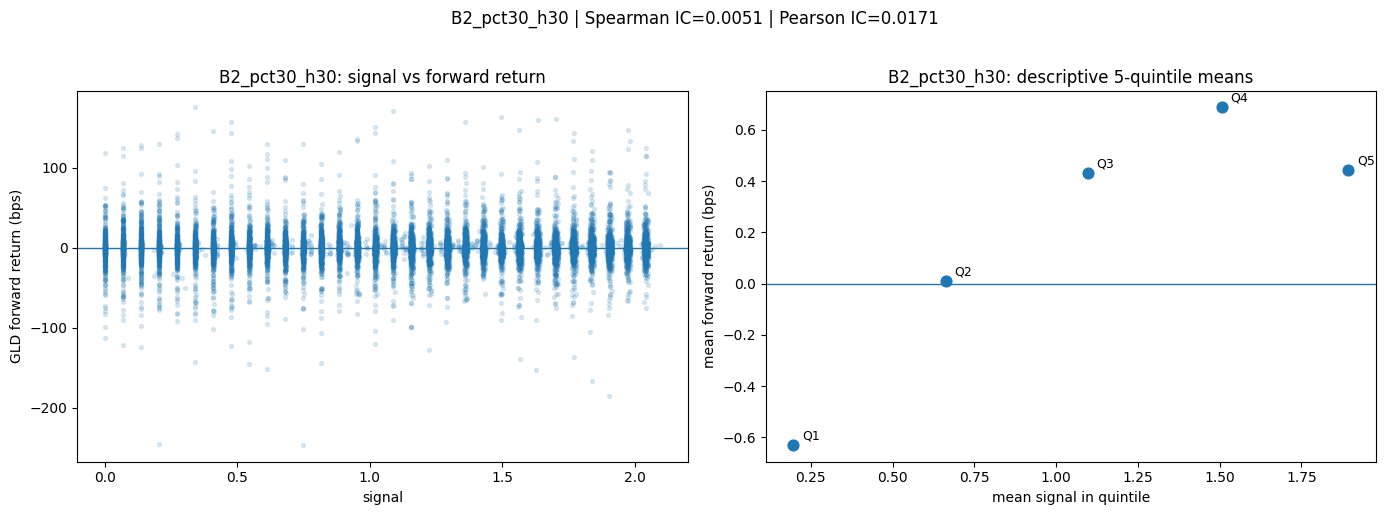

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.196961,-0.629327,2922
1,Q2,0.664124,0.011238,2922
2,Q3,1.096710,0.432275,2921
3,Q4,1.506948,0.687431,2922
4,Q5,1.894006,0.444212,2922


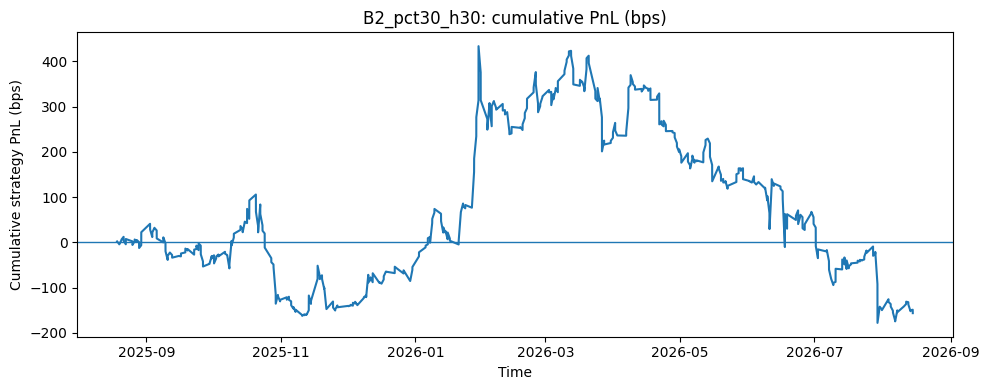


=== Candidate 2: B2_pct30_h10 ===
Specification: percentile_30 @ 10m GLD horizon
Entry rule (B.2 only): expanding historical 80th percentile, lag 1, long-only.


,candidate,horizon,pearson_ic,spearman_ic,n_obs,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days
0,B2_pct30_h10,10,0.007209,0.003314,14651,0.110989,0.507677,0.250255,0.315805,977,245


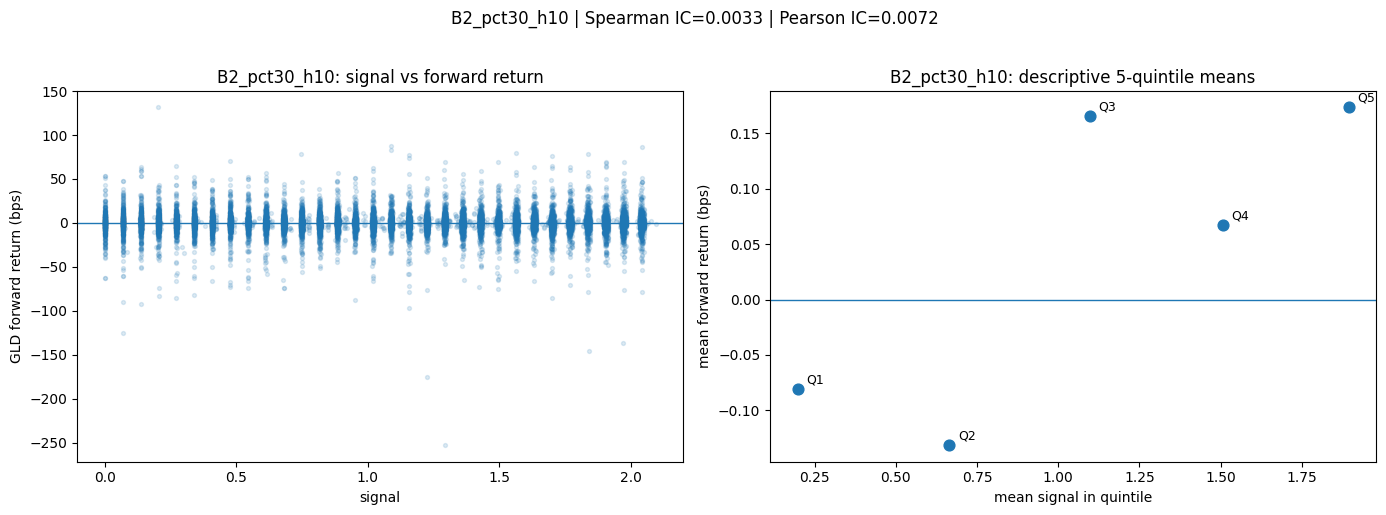

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.197308,-0.080834,2931
1,Q2,0.664796,-0.131114,2930
2,Q3,1.097638,0.165953,2930
3,Q4,1.507721,0.067336,2930
4,Q5,1.894280,0.173363,2930


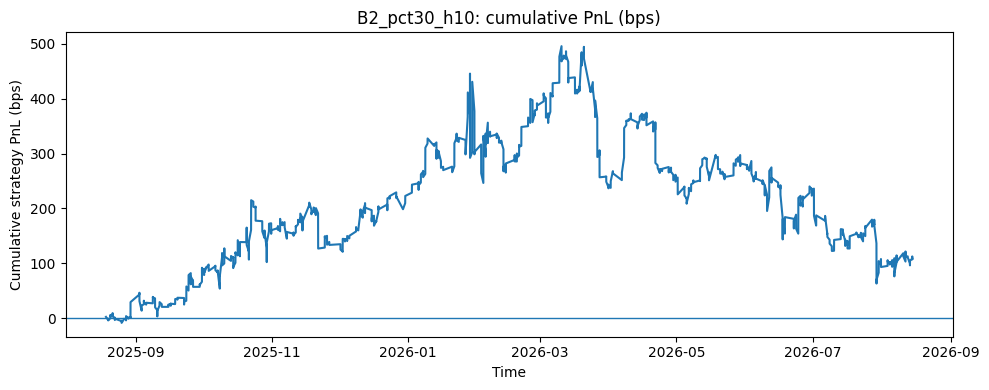


=== B2 baseline comparison (same horizon) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,B2_pct30_h30,30,False,0.017110,0.005111,0.016617,-0.000850,0.000493,candidate beats baseline
1,B2_pct30_h10,10,False,0.007209,0.003314,0.004750,0.004275,0.002459,candidate beats baseline


In [44]:
b2_top_two = rank_top_two(b2_results)
b2_signal_map = {"percentile_30": "GC_signal_pct"}

b2_top_two_display = b2_top_two.copy()
b2_top_two_display["candidate_id"] = b2_top_two_display.apply(
    lambda r: f"B2_{r['spec_slug']}_h{int(r['horizon'])}", axis=1
)
b2_top_two_display["baseline_equivalent"] = False

display(b2_top_two_display)
# B.2 top-two diagnostics
# B.2 is the only subsection that applies expanding-q80 entry for the metric package.
b2_stored = {}
b2_compare_rows = []

for rank, row in b2_top_two.iterrows():
    spec = row["spec_label"]
    horizon = int(row["horizon"])
    signal_col = b2_signal_map[spec]
    cid = f"B2_{row['spec_slug']}_h{horizon}"

    print(f"\n=== Candidate {rank + 1}: {cid} ===")
    print(f"Specification: {spec} @ {horizon}m GLD horizon")
    print("Entry rule (B.2 only): expanding historical 80th percentile, lag 1, long-only.")

    sample = horizon_specific_sample(signal_col, horizon)
    ic = compute_close_ic(signal_col, horizon)

    # signal history first, then attach this horizon's target
    close = (
        (data["Time"].dt.time >= time(15, 0)) &
        (data["Time"].dt.time < time(16, 0))
    )
    hist = (
        data.loc[close, ["Time", "date", signal_col]]
        .dropna(subset=[signal_col])
        .sort_values("Time")
        .rename(columns={signal_col: "signal"})
    )
    thresh = hist["signal"].expanding(min_periods=50).quantile(0.80).shift(1)
    hist["position"] = (hist["signal"] > thresh).astype(float).where(thresh.notna())

    fwd = f"GLD_fwd_{horizon}m"
    fwd_bps = f"GLD_fwd_{horizon}m_bps"
    strat = hist.merge(data[["Time", fwd, fwd_bps]], on="Time", how="left")
    strat = strat.rename(columns={fwd: "fwd_return", fwd_bps: "fwd_return_bps"})
    strat = strat.dropna(subset=["fwd_return"])
    trades = build_nonoverlapping_trades(strat.dropna(subset=["position"]), horizon)

    strat = summarize_strategy_returns(trades)
    metrics = {
        "candidate": cid,
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        "n_obs": ic["n_obs"],
        "avg_bps_per_trade": strat["avg_bps"],
        "hit_rate": strat["hit_rate"],
        "sharpe": strat["sharpe"],
        "sortino": strat["sortino"],
        "n_trades": strat["n_obs"],
        "n_days": strat["n_days"],
    }
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, trades)

    b2_compare_rows.append(
        baseline_comparison_row(cid, signal_col, horizon, baseline_equivalent=False)
    )
    b2_stored[cid] = (metrics, sample, trades)

b2_compare = pd.DataFrame(b2_compare_rows)
print("\n=== B2 baseline comparison (same horizon) ===")
display(b2_compare)



#### B.2 assessment

**Signal screen:** At the 30-minute GLD horizon, percentile IC (0.017110) is only marginally above baseline mean-ratio IC (0.016617) on Pearson. It is not a clear standalone improvement.

**Baseline comparison:** Percentile @ 30m marginally beats baseline on Pearson IC; percentile @ 10m beats baseline at 10m. The 30m Pearson lift is small and strategy diagnostics remain weak.

**Entry rule note:** B.2 is the only subsection that applies an expanding historical 80th-percentile long-only entry for trade diagnostics.

**Decision:** Record the top-two percentile×horizon cells from the 4-cell B.2 grid for later consolidation after A–E.



#### B.3 Linear ratio vs log-ratio

Compare the linear mean ratio with log(current / prior 30-minute mean).
Invalid or non-positive inputs are set to NaN so they drop out of the IC.


**Mathematical definition**

With the same prior mean $\mu_t^{(30)}$:

$$
\mathrm{Raw}_t^{\mathrm{lin}} = \frac{V_t}{\mu_t^{(30)}}
$$

$$
\mathrm{Raw}_t^{\mathrm{log}} = \log\!\left(\frac{V_t}{\mu_t^{(30)}}\right)
\quad(\text{non-positive inputs }\mapsto\ \mathrm{NaN})
$$

$$
S_t^{\cdot} = \frac{\mathrm{Raw}_t^{\cdot}}{\mathrm{mean}(|\mathrm{Raw}_s^{\cdot}|)_{s<t}}
$$

Only the raw transform (linear vs log) changes. Evaluated by $\mathrm{IC}_h$.


In [45]:
# linear vs log ratio (same prior mean)
# raw_mean already exists from B.1

raw_log = np.log(data["GC_volume"] / gc_prior_mean_30)
raw_log = raw_log.replace([np.inf, -np.inf], np.nan)
raw_log = raw_log.where(
    (data["GC_volume"] > 0) & (gc_prior_mean_30 > 0)
)

data["GC_signal_log"] = raw_log / (
    raw_log.abs().expanding(min_periods=30).mean().shift(1)
)

# linear already stored as GC_signal_mean

In [46]:
# B.3 full screen: linear vs log ratio × horizon
b3_results = []

for label, col, slug in [
    ("linear_mean", "GC_signal_mean", "linear"),
    ("log_mean", "GC_signal_log", "log"),
]:
    for h in horizons:
        stats = compute_close_ic(col, h)
        b3_results.append({
            "spec_label": label,
            "spec_slug": slug,
            "horizon": h,
            "pearson_ic": stats["pearson_ic"],
            "spearman_ic": stats["spearman_ic"],
            "n_obs": stats["n_obs"],
        })

b3_results = pd.DataFrame(b3_results)
b3_ic = b3_results.pivot(index="spec_label", columns="horizon", values="pearson_ic")
b3_ic



horizon,1,5,10,30
spec_label,,,,
linear_mean,-0.003982,0.000964,0.004750,0.016617
log_mean,0.000121,0.001168,0.008696,0.012727


#### B.3 top-two selection


,spec_label,spec_slug,horizon,pearson_ic,spearman_ic,n_obs,candidate_id,baseline_equivalent
0,linear_mean,linear,30,0.016617,-0.000850,14609,B3_linear_h30,True
1,log_mean,log,30,0.012727,-0.001338,14609,B3_log_h30,False



=== Candidate 1: B3_linear_h30 ===
Specification: linear_mean @ 30m GLD horizon
Note: baseline-equivalent construction within this subsection.


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,B3_linear_h30,30,0.016617,-0.00085,0.593722,0.500787,0.699926,1.155564,14609,246


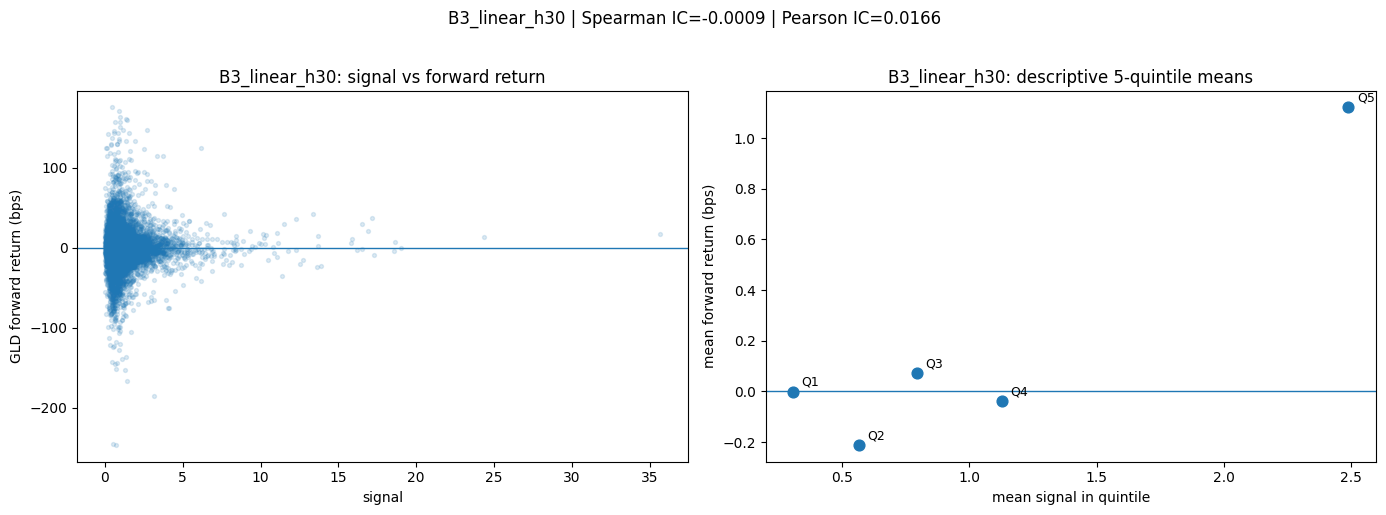

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.306711,-0.000163,2922
1,Q2,0.563290,-0.210544,2922
2,Q3,0.794376,0.072188,2921
3,Q4,1.126442,-0.036384,2922
4,Q5,2.491887,1.120609,2922


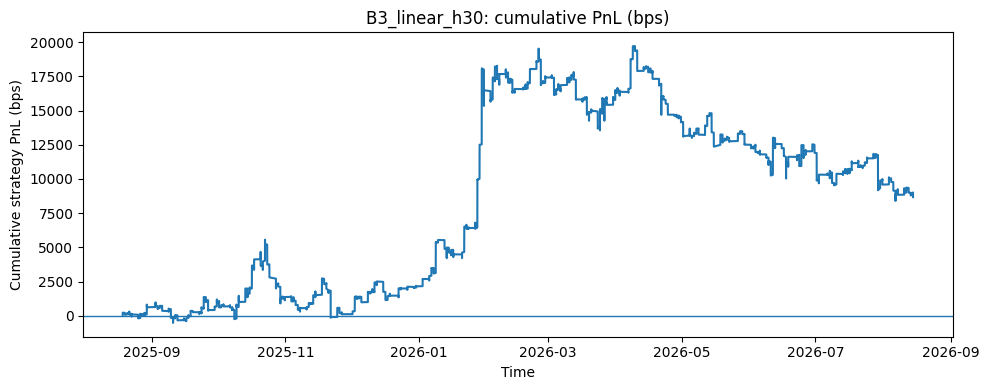


=== Candidate 2: B3_log_h30 ===
Specification: log_mean @ 30m GLD horizon


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,B3_log_h30,30,0.012727,-0.001338,0.281605,0.495996,0.600194,0.81059,14609,246


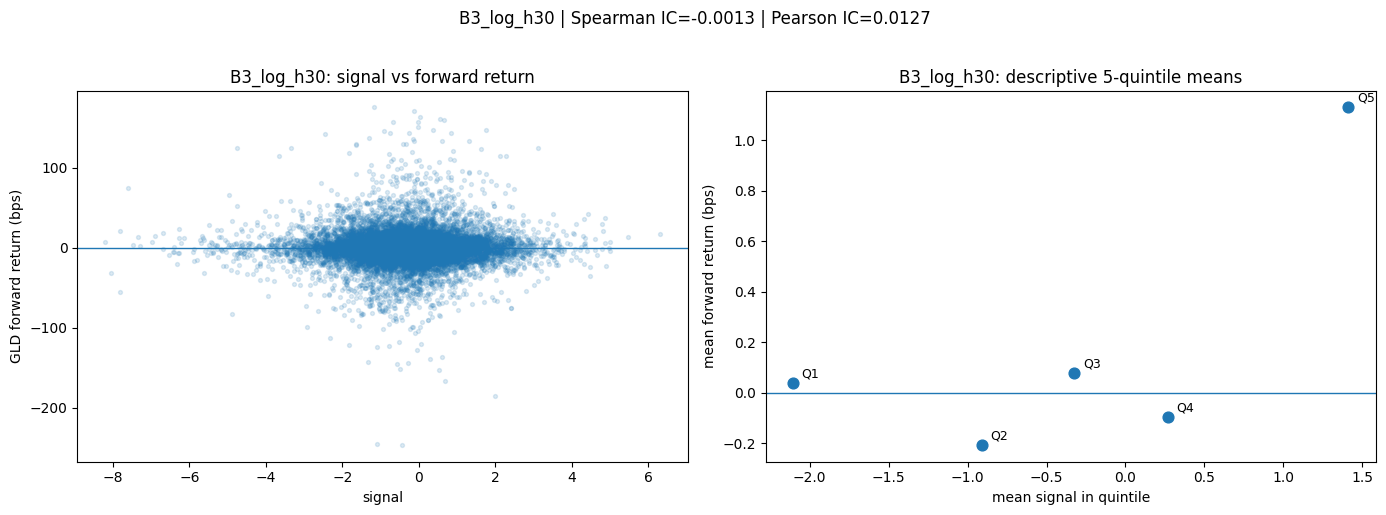

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,-2.103421,0.039230,2922
1,Q2,-0.910177,-0.205684,2922
2,Q3,-0.322880,0.078191,2921
3,Q4,0.266513,-0.096537,2922
4,Q5,1.412609,1.130508,2922


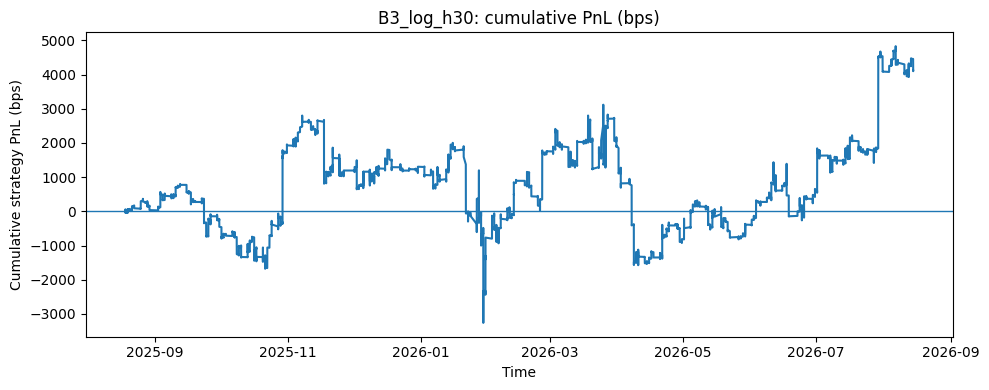


=== B3 baseline comparison (same horizon) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,B3_linear_h30,30,True,0.016617,-0.000850,0.016617,-0.00085,0.00000,baseline-equivalent / tied
1,B3_log_h30,30,False,0.012727,-0.001338,0.016617,-0.00085,-0.00389,baseline beats candidate


In [47]:
b3_top_two = rank_top_two(b3_results)
b3_signal_map = {"linear_mean": "GC_signal_mean", "log_mean": "GC_signal_log"}

b3_top_two_display = b3_top_two.copy()
b3_top_two_display["candidate_id"] = b3_top_two_display.apply(
    lambda r: f"B3_{r['spec_slug']}_h{int(r['horizon'])}", axis=1
)
b3_top_two_display["baseline_equivalent"] = b3_top_two_display["spec_label"].eq("linear_mean")

display(b3_top_two_display)
# top-two diagnostics: IC + selected-candidate metric package + plots
b3_stored = {}
b3_compare_rows = []

for rank, row in b3_top_two.iterrows():
    spec = row["spec_label"]
    horizon = int(row["horizon"])
    signal_col = b3_signal_map[spec]
    cid = f"B3_{row['spec_slug']}_h{horizon}"
    is_base = spec == "linear_mean"

    print(f"\n=== Candidate {rank + 1}: {cid} ===")
    print(f"Specification: {spec} @ {horizon}m GLD horizon")
    if is_base:
        print("Note: baseline-equivalent construction within this subsection.")

    sample = horizon_specific_sample(signal_col, horizon)
    ic = compute_close_ic(signal_col, horizon)
    strategy = continuous_strategy_frame(sample)
    metrics = {
        "candidate": cid,
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        **summarize_strategy_returns(strategy),
    }
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, strategy)

    b3_compare_rows.append(
        baseline_comparison_row(cid, signal_col, horizon, baseline_equivalent=is_base)
    )
    b3_stored[cid] = (metrics, sample, strategy)

b3_compare = pd.DataFrame(b3_compare_rows)
print(f"\n=== B3 baseline comparison (same horizon) ===")
display(b3_compare)



#### B.3 assessment

**Signal screen:** Log-ratio does not improve on the linear mean ratio at the useful close horizons (30m Pearson IC 0.012727 vs 0.016617).

**Within-subsection ranking:** Linear mean @ 30m and log mean @ 30m are the top-two Pearson IC cells in the 8-cell grid.

**Baseline comparison:** Linear mean @ 30m is baseline-equivalent / tied; log mean @ 30m is **below baseline** at 30m.

**Decision:** Record both top-two cells. Linear mean remains the baseline-equivalent construction; log compression weakens useful-horizon IC.



#### B.4 Total vs uptick vs downtick volume

Build the same 30-minute mean-ratio + expanding-normalization surge on:
- GC_volume
- GC_uptick_volume
- GC_downtick_volume


**Mathematical definition**

Define three volume fields (not an imbalance ratio):

$$
V_t^{\mathrm{total}} = \texttt{GC\_volume},\quad
V_t^{\mathrm{up}} = \texttt{GC\_uptick\_volume},\quad
V_t^{\mathrm{down}} = \texttt{GC\_downtick\_volume}
$$

For each field $V^{(\cdot)}$ independently, apply the **same** baseline surge transform:

$$
\mathrm{Raw}_t^{(\cdot)} = \frac{V_t^{(\cdot)}}{\mathrm{mean}(V_{t-1}^{(\cdot)},\ldots,V_{t-30}^{(\cdot)})},\qquad
S_t^{(\cdot)} = \frac{\mathrm{Raw}_t^{(\cdot)}}{\mathrm{mean}(|\mathrm{Raw}_s^{(\cdot)}|)_{s<t}}
$$

This subsection substitutes the underlying volume series while keeping lookback, linear ratio, and expanding normalization fixed. It does **not** construct $(V^{\mathrm{up}}-V^{\mathrm{down}})/V^{\mathrm{total}}$.

Evaluated by $\mathrm{IC}_h = \mathrm{Corr}(S_t^{(\cdot)}, R_{t,t+h})$.


In [48]:
# total / uptick / downtick surge signals
tick_fields = {
    "total": "GC_volume",
    "uptick": "GC_uptick_volume",
    "downtick": "GC_downtick_volume",
}

for label, col in tick_fields.items():
    prior = (
        data[col]
        .shift(1)
        .rolling(window=30, min_periods=5)
        .mean()
    )
    raw = data[col] / prior
    data[f"GC_signal_{label}"] = raw / (
        raw.abs().expanding(min_periods=30).mean().shift(1)
    )

In [49]:
# close-window IC
tick_results = []

for label in tick_fields:
    col = f"GC_signal_{label}"

    for h in horizons:
        temp = data[
            (data["Time"].dt.time >= time(15, 0)) &
            (data["Time"].dt.time < time(16, 0))
        ][[col, f"GLD_fwd_{h}m"]].dropna()

        tick_results.append({
            "construction": label,
            "horizon": h,
            "IC": temp[col].corr(temp[f"GLD_fwd_{h}m"]),
            "n_obs": len(temp)
        })

tick_results = pd.DataFrame(tick_results)

tick_ic = tick_results.pivot(
    index="construction",
    columns="horizon",
    values="IC"
)

tick_ic

horizon,1,5,10,30
construction,,,,
downtick,-0.020735,-0.002922,-0.001572,0.010093
total,-0.003982,0.000964,0.004750,0.016617
uptick,0.035301,0.009585,0.016749,0.015666


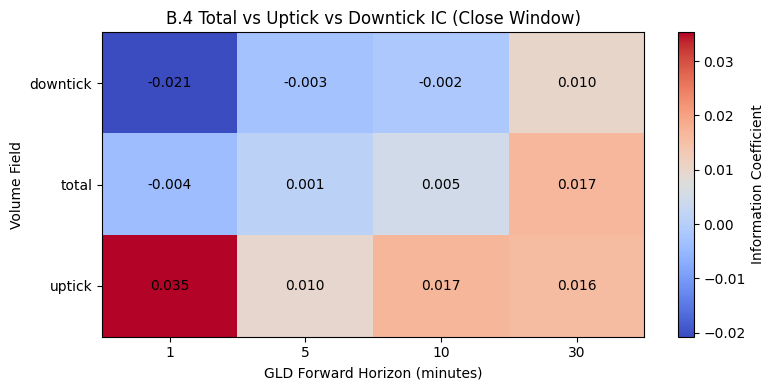

In [50]:
# heatmap for tick constructions
plt.figure(figsize=(8, 4))

plt.imshow(tick_ic.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Information Coefficient")

plt.xticks(range(len(tick_ic.columns)), tick_ic.columns)
plt.yticks(range(len(tick_ic.index)), tick_ic.index)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Volume Field")
plt.title("B.4 Total vs Uptick vs Downtick IC (Close Window)")

for i in range(len(tick_ic.index)):
    for j in range(len(tick_ic.columns)):
        plt.text(
            j, i,
            f"{tick_ic.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#### B.4 top-two selection


,spec_label,spec_slug,horizon,pearson_ic,spearman_ic,n_obs,candidate_id,baseline_equivalent
0,uptick,uptick,1,0.035301,0.100261,14653,B4_uptick_h1,False
1,uptick,uptick,10,0.016749,0.028392,14651,B4_uptick_h10,False



=== Candidate 1: B4_uptick_h1 ===
Specification: uptick @ 1m GLD horizon


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,B4_uptick_h1,1,0.035301,0.100261,0.215755,0.50174,3.058789,4.47274,14653,246


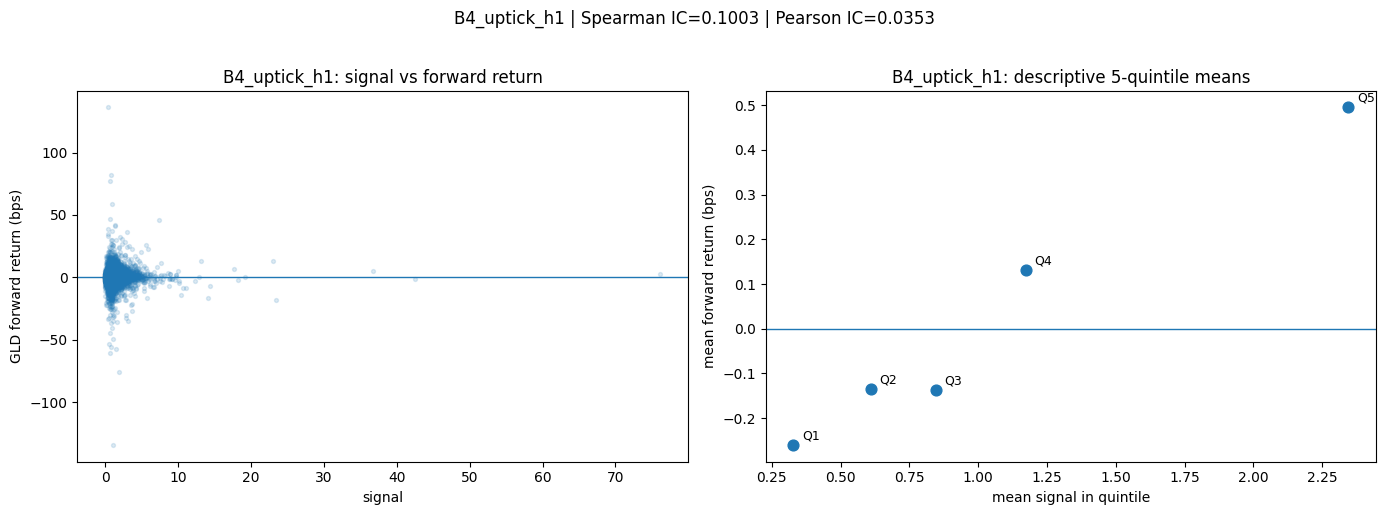

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.328477,-0.259883,2931
1,Q2,0.610406,-0.134511,2930
2,Q3,0.847166,-0.137896,2931
3,Q4,1.172254,0.130637,2930
4,Q5,2.345662,0.495068,2931


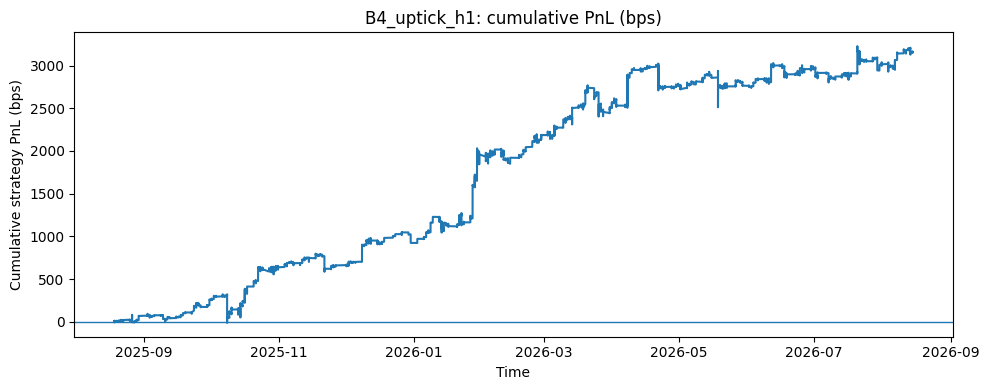


=== Candidate 2: B4_uptick_h10 ===
Specification: uptick @ 10m GLD horizon


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,B4_uptick_h10,10,0.016749,0.028392,0.299638,0.504948,0.724769,0.938074,14651,246


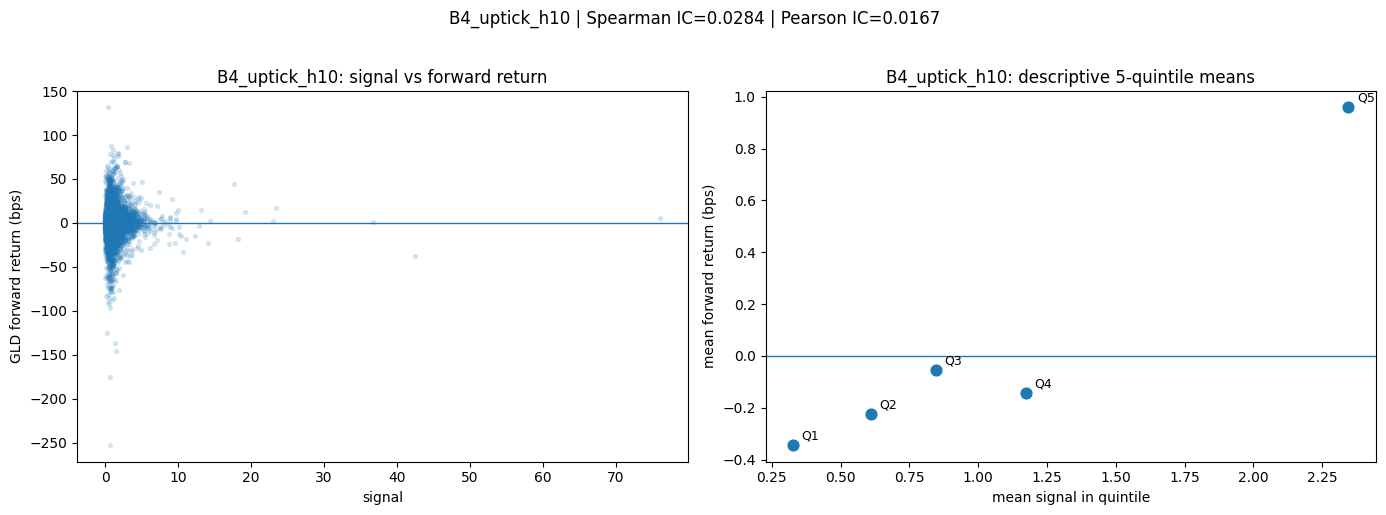

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.328477,-0.343301,2931
1,Q2,0.610406,-0.222812,2930
2,Q3,0.847119,-0.054594,2930
3,Q4,1.172144,-0.143294,2930
4,Q5,2.345346,0.958796,2930


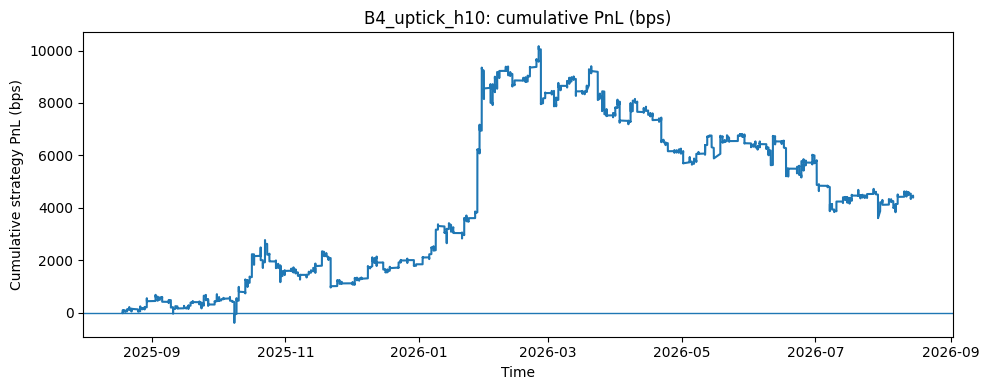


=== B4 baseline comparison (same horizon) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,B4_uptick_h1,1,False,0.035301,0.100261,-0.003982,0.006929,0.039282,candidate beats baseline
1,B4_uptick_h10,10,False,0.016749,0.028392,0.004750,0.004275,0.011999,candidate beats baseline


In [51]:
# B.4 full screen with Pearson + Spearman for ranking
b4_rows = []
for label in tick_fields:
    col = f"GC_signal_{label}"
    for h in horizons:
        stats = compute_close_ic(col, h)
        b4_rows.append({
            "spec_label": label,
            "spec_slug": label,
            "horizon": h,
            "pearson_ic": stats["pearson_ic"],
            "spearman_ic": stats["spearman_ic"],
            "n_obs": stats["n_obs"],
        })

b4_results = pd.DataFrame(b4_rows)
b4_top_two = rank_top_two(b4_results)
b4_signal_map = {k: f"GC_signal_{k}" for k in tick_fields}

b4_top_two_display = b4_top_two.copy()
b4_top_two_display["candidate_id"] = b4_top_two_display.apply(
    lambda r: f"B4_{r['spec_slug']}_h{int(r['horizon'])}", axis=1
)
b4_top_two_display["baseline_equivalent"] = b4_top_two_display["spec_label"].eq("total")

display(b4_top_two_display)
# top-two diagnostics: IC + selected-candidate metric package + plots
b4_stored = {}
b4_compare_rows = []

for rank, row in b4_top_two.iterrows():
    spec = row["spec_label"]
    horizon = int(row["horizon"])
    signal_col = b4_signal_map[spec]
    cid = f"B4_{row['spec_slug']}_h{horizon}"
    is_base = spec == "total"

    print(f"\n=== Candidate {rank + 1}: {cid} ===")
    print(f"Specification: {spec} @ {horizon}m GLD horizon")
    if is_base:
        print("Note: baseline-equivalent construction within this subsection.")

    sample = horizon_specific_sample(signal_col, horizon)
    ic = compute_close_ic(signal_col, horizon)
    strategy = continuous_strategy_frame(sample)
    metrics = {
        "candidate": cid,
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        **summarize_strategy_returns(strategy),
    }
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, strategy)

    b4_compare_rows.append(
        baseline_comparison_row(cid, signal_col, horizon, baseline_equivalent=is_base)
    )
    b4_stored[cid] = (metrics, sample, strategy)

b4_compare = pd.DataFrame(b4_compare_rows)
print(f"\n=== B4 baseline comparison (same horizon) ===")
display(b4_compare)


#### B.4 assessment

**Signal screen:** Uptick surge is clearly stronger than total or downtick, especially at 1m (Pearson IC 0.035301 vs total -0.003982 at 1m). This is **uptick volume / rolling mean uptick volume**, not an up-minus-down imbalance.

**Within-subsection ranking:** Uptick @ 1m and uptick @ 10m are the top-two Pearson IC cells in the 12-cell grid (not uptick @ 30m).

**Baseline comparison:** Both retained uptick cells beat baseline Pearson IC at their respective horizons. Selected-candidate metric package (including cumulative PnL) is reported for the retained cells.

**Decision:** Record the top-two total/uptick/downtick × horizon cells. Uptick at 1m is the substantive standout in this subsection.



#### B.5 Instrument sets

One-axis screen of activity sources under fixed controls:
- local lookback = 30 minutes (mean denominator)
- expanding normalization
- Close session (15:00-16:00)
- GLD forward horizons 1/5/10/30

**Equity symbols used for the ETF basket:** GLD, GLDM, IAU, IAUM
(verified from `equity_60.csv`).

**ETF basket activity (simple unweighted sum of traded volume):**

`ETF_basket_volume = sum(vwap_traded_volume across GLD, GLDM, IAU, IAUM at each Time)`

GLD remains the prediction target and is kept as its own minute panel.
ETF activity is aggregated separately by Time, then merged — so GLD rows are not duplicated.

**GC + MGC ounce-equivalent:**

`GC_volume * 100 + MGC_volume * 10`

**Futures / ETF cross-ratio:** `GC_volume / ETF_basket_volume`, then the same surge transform.


**Mathematical definition**

Activity series tested (then each receives the same baseline surge transform):

$$
X_t^{\mathrm{GC}} = V_t^{\mathrm{GC}}
$$

$$
X_t^{\mathrm{MGC}} = V_t^{\mathrm{MGC}}
$$

$$
X_t^{\mathrm{GC+MGC}} = 100\,V_t^{\mathrm{GC}} + 10\,V_t^{\mathrm{MGC}}
\quad(\text{ounce-equivalent activity proxy})
$$

$$
X_t^{\mathrm{ETF}} = \sum_{s \in \{\mathrm{GLD},\mathrm{GLDM},\mathrm{IAU},\mathrm{IAUM}\}} \texttt{vwap\_traded\_volume}_{s,t}
\quad(\text{unweighted volume sum})
$$

$$
X_t^{\mathrm{GC/ETF}} = \frac{V_t^{\mathrm{GC}}}{X_t^{\mathrm{ETF}}}
$$

For each $X$, with $L=30$:

$$
S_t^{(X)} = \frac{X_t / \mu_t^{(30)}(X)}{\mathrm{mean}\big(|X_s/\mu_s^{(30)}(X)|\big)_{s<t}}
$$

Only the activity series $X$ changes. Evaluated by $\mathrm{IC}_h = \mathrm{Corr}(S_t^{(X)}, R_{t,t+h})$.


In [52]:
# verify ETF symbols in the loaded equity file
print("Equity symbols:")
print(equity["symbol"].value_counts())

etf_symbols = ["GLD", "GLDM", "IAU", "IAUM"]
missing = [s for s in etf_symbols if s not in set(equity["symbol"].unique())]
print("Missing basket symbols:", missing if missing else "none")


Equity symbols:
symbol
GLD     233392
IAU     210042
GLDM    199144
IAUM    160776
Name: count, dtype: int64


Missing basket symbols: none


In [53]:
# ETF basket activity: aggregate by Time only (do not expand the GLD target panel)
etf_activity = (
    equity[equity["symbol"].isin(etf_symbols)]
    .groupby("Time", as_index=False)
    .agg(ETF_basket_volume=("vwap_traded_volume", "sum"))
)

# drop prior ETF basket column if re-running this cell
if "ETF_basket_volume" in data.columns:
    data = data.drop(columns=["ETF_basket_volume"])

# merge minute-level ETF basket into the existing GLD+futures panel
data = pd.merge(data, etf_activity, on="Time", how="left")

# ounce-equivalent futures activity
data["GC_oz"] = data["GC_volume"] * 100
data["MGC_oz"] = data["MGC_volume"] * 10
data["GC_MGC_oz"] = data["GC_oz"] + data["MGC_oz"]

# futures / ETF basket cross-ratio level
data["GC_over_ETF"] = data["GC_volume"] / data["ETF_basket_volume"]

print("data rows:", len(data), "| unique Times:", data["Time"].nunique())
print("ETF_basket_volume null pct:", data["ETF_basket_volume"].isna().mean())


data rows: 233392 | unique Times: 233392
ETF_basket_volume null pct: 0.0


In [54]:
# B.5 instrument surge signals (same 30m mean + expanding norm)
instrument_fields = {
    "GC": "GC_volume",
    "MGC": "MGC_volume",
    "GC_MGC_oz": "GC_MGC_oz",
    "ETF_basket": "ETF_basket_volume",
    "GC_over_ETF": "GC_over_ETF",
}

for label, col in instrument_fields.items():
    prior = (
        data[col]
        .shift(1)
        .rolling(window=30, min_periods=5)
        .mean()
    )
    raw = data[col] / prior
    raw = raw.replace([np.inf, -np.inf], np.nan)
    data[f"signal_{label}"] = raw / (
        raw.abs().expanding(min_periods=30).mean().shift(1)
    )


In [55]:
# close-window IC screen
instrument_results = []

for label in instrument_fields:
    col = f"signal_{label}"

    for h in horizons:
        temp = data[
            (data["Time"].dt.time >= time(15, 0)) &
            (data["Time"].dt.time < time(16, 0))
        ][[col, f"GLD_fwd_{h}m"]].dropna()

        instrument_results.append({
            "construction": label,
            "horizon": h,
            "IC": temp[col].corr(temp[f"GLD_fwd_{h}m"]),
            "n_obs": len(temp),
        })

instrument_results = pd.DataFrame(instrument_results)

instrument_ic = instrument_results.pivot(
    index="construction",
    columns="horizon",
    values="IC",
).reindex(list(instrument_fields.keys()))

instrument_ic


horizon,1,5,10,30
construction,,,,
GC,-0.003982,0.000964,0.004750,0.016617
MGC,-0.007394,0.003395,0.008916,0.014011
GC_MGC_oz,-0.004586,-0.000433,0.006680,0.016358
ETF_basket,0.011531,0.010153,0.008676,0.013819
GC_over_ETF,0.002091,-0.005174,-0.003753,0.005016


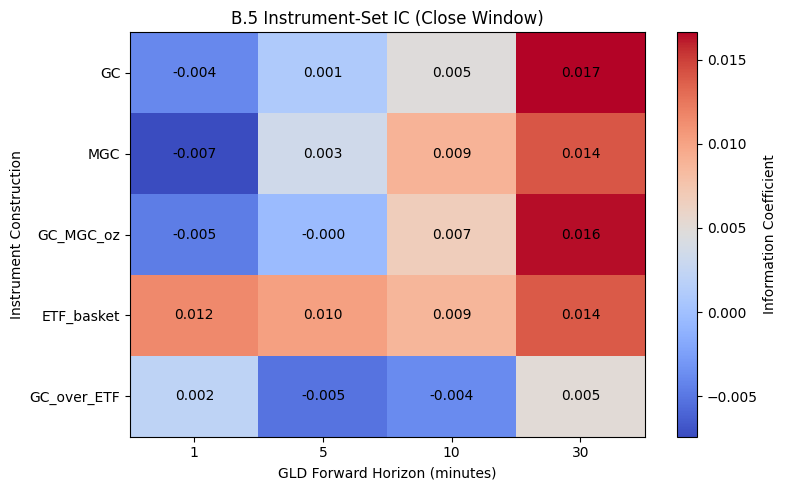

In [56]:
# heatmap of the B.5 instrument IC screen
plt.figure(figsize=(8, 5))

plt.imshow(instrument_ic.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Information Coefficient")

plt.xticks(range(len(instrument_ic.columns)), instrument_ic.columns)
plt.yticks(range(len(instrument_ic.index)), instrument_ic.index)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Instrument Construction")
plt.title("B.5 Instrument-Set IC (Close Window)")

for i in range(len(instrument_ic.index)):
    for j in range(len(instrument_ic.columns)):
        plt.text(
            j, i,
            f"{instrument_ic.iloc[i, j]:.3f}",
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()


#### B.5 top-two selection


,spec_label,spec_slug,horizon,pearson_ic,spearman_ic,n_obs,candidate_id,baseline_equivalent
0,GC,gc,30,0.016617,-0.000850,14609,B5_gc_h30,True
1,GC_MGC_oz,gc_mgc_oz,30,0.016358,-0.006086,13526,B5_gc_mgc_oz_h30,False



=== Candidate 1: B5_gc_h30 ===
Specification: GC @ 30m GLD horizon
Note: baseline-equivalent construction within this subsection.


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,B5_gc_h30,30,0.016617,-0.00085,0.593722,0.500787,0.699926,1.155564,14609,246


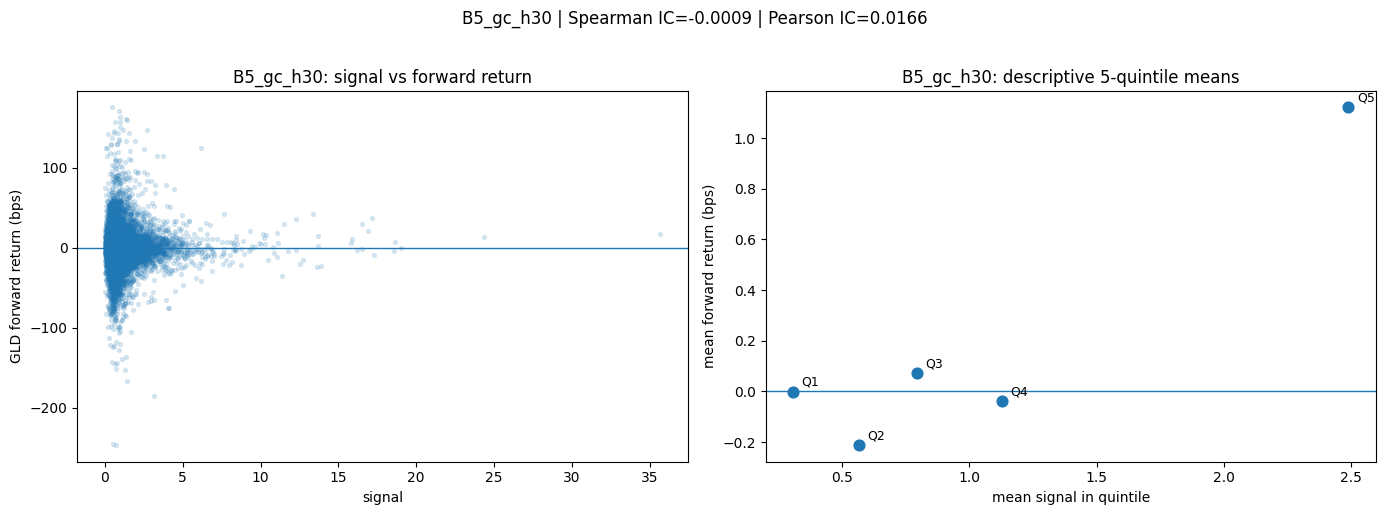

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.306711,-0.000163,2922
1,Q2,0.563290,-0.210544,2922
2,Q3,0.794376,0.072188,2921
3,Q4,1.126442,-0.036384,2922
4,Q5,2.491887,1.120609,2922


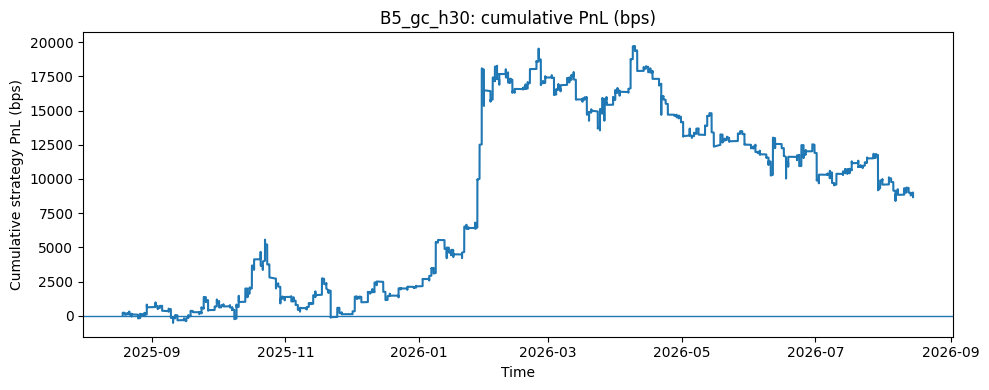


=== Candidate 2: B5_gc_mgc_oz_h30 ===
Specification: GC_MGC_oz @ 30m GLD horizon


,candidate,horizon,pearson_ic,spearman_ic,avg_bps,hit_rate,sharpe,sortino,n_obs,n_days
0,B5_gc_mgc_oz_h30,30,0.016358,-0.006086,0.463475,0.5,0.532518,0.883752,13526,227


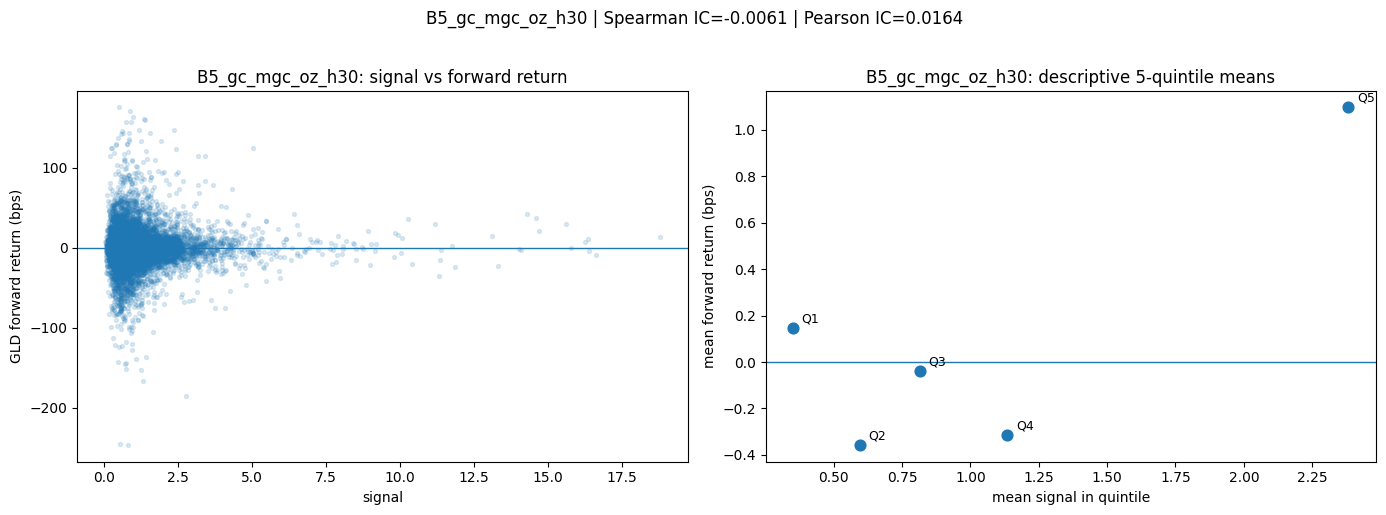

,plot_quintile,mean_signal,mean_fwd_bps,n
0,Q1,0.352936,0.147903,2706
1,Q2,0.595222,-0.356713,2705
2,Q3,0.815229,-0.039829,2705
3,Q4,1.135554,-0.314899,2705
4,Q5,2.382535,1.096151,2705


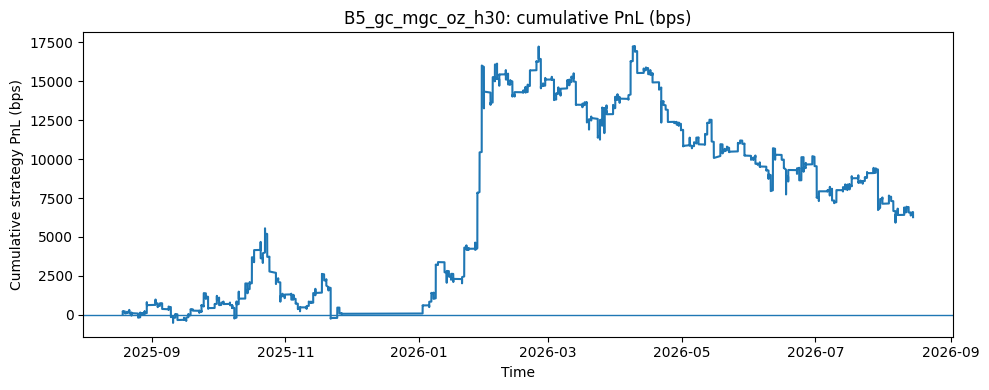


=== B5 baseline comparison (same horizon) ===


,candidate,horizon,baseline_equivalent,candidate_pearson_ic,candidate_spearman_ic,baseline_pearson_ic,baseline_spearman_ic,pearson_ic_delta,verdict
0,B5_gc_h30,30,True,0.016617,-0.000850,0.016617,-0.00085,0.000000,baseline-equivalent / tied
1,B5_gc_mgc_oz_h30,30,False,0.016358,-0.006086,0.016617,-0.00085,-0.000259,baseline beats candidate


In [57]:
b5_rows = []
for label in instrument_fields:
    col = f"signal_{label}"
    for h in horizons:
        stats = compute_close_ic(col, h)
        b5_rows.append({
            "spec_label": label,
            "spec_slug": label.lower().replace("+", "plus").replace("/", "over"),
            "horizon": h,
            "pearson_ic": stats["pearson_ic"],
            "spearman_ic": stats["spearman_ic"],
            "n_obs": stats["n_obs"],
        })

b5_results = pd.DataFrame(b5_rows)
b5_top_two = rank_top_two(b5_results)
b5_signal_map = {label: f"signal_{label}" for label in instrument_fields}

b5_top_two_display = b5_top_two.copy()
b5_top_two_display["candidate_id"] = b5_top_two_display.apply(
    lambda r: f"B5_{r['spec_slug']}_h{int(r['horizon'])}", axis=1
)
b5_top_two_display["baseline_equivalent"] = b5_top_two_display["spec_label"].eq("GC")

display(b5_top_two_display)
# top-two diagnostics: IC + selected-candidate metric package + plots
b5_stored = {}
b5_compare_rows = []

for rank, row in b5_top_two.iterrows():
    spec = row["spec_label"]
    horizon = int(row["horizon"])
    signal_col = b5_signal_map[spec]
    cid = f"B5_{row['spec_slug']}_h{horizon}"
    is_base = spec == "GC"

    print(f"\n=== Candidate {rank + 1}: {cid} ===")
    print(f"Specification: {spec} @ {horizon}m GLD horizon")
    if is_base:
        print("Note: baseline-equivalent construction within this subsection.")

    sample = horizon_specific_sample(signal_col, horizon)
    ic = compute_close_ic(signal_col, horizon)
    strategy = continuous_strategy_frame(sample)
    metrics = {
        "candidate": cid,
        "horizon": horizon,
        "pearson_ic": ic["pearson_ic"],
        "spearman_ic": ic["spearman_ic"],
        **summarize_strategy_returns(strategy),
    }
    display(pd.DataFrame([metrics]))
    plot_candidate_diagnostics(cid, sample, strategy)

    b5_compare_rows.append(
        baseline_comparison_row(cid, signal_col, horizon, baseline_equivalent=is_base)
    )
    b5_stored[cid] = (metrics, sample, strategy)

b5_compare = pd.DataFrame(b5_compare_rows)
print(f"\n=== B5 baseline comparison (same horizon) ===")
display(b5_compare)



#### B.5 assessment

**Signal screen:** GC @ 30m Pearson IC 0.016617 remains the strongest unsigned futures construction in this instrument grid. ETF basket, MGC-only, ounce-equivalent, and GC/ETF cross-ratio do not materially beat baseline GC on the close IC screen.

**Within-subsection ranking:** GC @ 30m and GC_MGC_oz @ 30m are the top-two Pearson IC cells in the 24-cell grid.

**Baseline comparison:** GC @ 30m is baseline-equivalent / tied; GC_MGC_oz @ 30m is **below baseline** at 30m.

**Decision:** Record both top-two cells. No alternative instrument set clearly replaces baseline GC under this one-axis screen.



### Section B - Conclusion

**Question:** Which definition of unusual volume best predicts future GLD returns under fair one-axis evaluation?

**What each subsection established**
- **B.1 (mean vs median):** Median Pearson IC is only slightly above mean (0.017526 vs 0.016617 at 30m). Selected-candidate metric package is reported below for the retained cells.
- **B.2 (percentile):** Percentile Pearson IC at 30m (0.017110) is only marginally above baseline (0.016617) — not a clear improvement.
- **B.3 (log-ratio):** Log compression weakens useful-horizon IC (30m 0.012727 vs linear 0.016617).
- **B.4 (total / uptick / downtick):** Uptick dominates, especially at 1m (Pearson IC ~0.035). Uptick = current uptick volume / rolling mean uptick volume, with the same expanding normalization.
- **B.5 (instruments):** GC mean-ratio remains strongest among tested instrument sets; alternatives are incremental or flat.

**Decision / takeaway:** Under fair one-axis evaluation, the best *definition of unusual volume* is **uptick-volume surge** (B.4), not a different unsigned ratio transform. Every B subsection retains two strongest cells for later consolidation after A–E with Section A findings — joint testing / a survivor registry is not created here.



### Baseline-equivalent validation


In [58]:
# validation: baseline-equivalent constructions vs baseline at each horizon
BASELINE_EQUIV_SPECS = [
    ("A.1 lookback=30", "GC_signal_30"),
    ("A.2 expanding", "GC_signal_expanding"),
    ("B.1 mean", "GC_signal_mean"),
    ("B.3 linear mean", "GC_signal_mean"),
    ("B.4 total", "GC_signal_total"),
    ("B.5 GC", "signal_GC"),
]

validation_rows = []
for label, signal_col in BASELINE_EQUIV_SPECS:
    for h in [1, 5, 10, 30]:
        cand = compute_close_ic(signal_col, h)
        base = compute_close_ic(BASELINE_SIGNAL_COL, h)
        pearson_diff = cand["pearson_ic"] - base["pearson_ic"]
        spearman_diff = cand["spearman_ic"] - base["spearman_ic"]
        if abs(pearson_diff) <= IC_TOLERANCE and abs(spearman_diff) <= IC_TOLERANCE and cand["n_obs"] == base["n_obs"]:
            status = "PASS"
        else:
            status = "INVESTIGATE"
        validation_rows.append({
            "construction": label,
            "signal_col": signal_col,
            "horizon": h,
            "candidate_pearson": cand["pearson_ic"],
            "baseline_pearson": base["pearson_ic"],
            "pearson_difference": pearson_diff,
            "candidate_spearman": cand["spearman_ic"],
            "baseline_spearman": base["spearman_ic"],
            "n_candidate": cand["n_obs"],
            "n_baseline": base["n_obs"],
            "status": status,
        })

baseline_equiv_validation = pd.DataFrame(validation_rows)
print("Baseline-equivalent validation (expect PASS for mathematically identical specs):")
baseline_equiv_validation


Baseline-equivalent validation (expect PASS for mathematically identical specs):


,construction,signal_col,horizon,candidate_pearson,baseline_pearson,pearson_difference,candidate_spearman,baseline_spearman,n_candidate,n_baseline,status
0,A.1 lookback=30,GC_signal_30,1,-0.003982,-0.003982,0.0,0.006929,0.006929,14653,14653,PASS
1,A.1 lookback=30,GC_signal_30,5,0.000964,0.000964,0.0,0.009340,0.009340,14653,14653,PASS
2,A.1 lookback=30,GC_signal_30,10,0.004750,0.004750,0.0,0.004275,0.004275,14651,14651,PASS
3,A.1 lookback=30,GC_signal_30,30,0.016617,0.016617,0.0,-0.000850,-0.000850,14609,14609,PASS
4,A.2 expanding,GC_signal_expanding,1,-0.003982,-0.003982,0.0,0.006929,0.006929,14653,14653,PASS
5,A.2 expanding,GC_signal_expanding,5,0.000964,0.000964,0.0,0.009340,0.009340,14653,14653,PASS
6,A.2 expanding,GC_signal_expanding,10,0.004750,0.004750,0.0,0.004275,0.004275,14651,14651,PASS
7,A.2 expanding,GC_signal_expanding,30,0.016617,0.016617,0.0,-0.000850,-0.000850,14609,14609,PASS
8,B.1 mean,GC_signal_mean,1,-0.003982,-0.003982,0.0,0.006929,0.006929,14653,14653,PASS
9,B.1 mean,GC_signal_mean,5,0.000964,0.000964,0.0,0.009340,0.009340,14653,14653,PASS


### Post-rerun exception notes

- **Baseline-equivalent in top-two:** A.2 expanding @ 30m, B.1 mean @ 30m, B.3 linear mean @ 30m, B.5 GC @ 30m — all validate as baseline-equivalent / tied under canonical horizon-specific sampling.
- **Top-two beats baseline on Pearson:** A.1 (both), A.2 rollnorm_1950 @ 30m, B.1 median @ 30m, B.2 (both), B.4 (both).
- **Top-two below baseline:** B.3 log @ 30m and B.5 GC_MGC_oz @ 30m rank second within their subsection but are below baseline at 30m on Pearson IC.
- **Metric package:** Selected-candidate tables include continuous strategy diagnostics (`avg_bps` / `n_obs` via signal * forward_return; B.2 selected diagnostics use local q80 entry with trade counts). No max drawdown. Ranking remains signed Pearson IC only.
- **Sample sizes:** Horizon-specific n_obs differ by horizon (e.g. 14653 @ 1m/5m, 14651 @ 10m, 14609 @ 30m) because missing GLD targets are dropped per horizon, not jointly across all horizons.


### Remaining helper inventory

| Helper | Why it remains |
|---|---|
| `horizon_specific_sample` | One canonical Close-session / horizon sample for baseline and candidates |
| `compute_close_ic` | Shared Pearson + Spearman IC on that sample |
| `rank_top_two` | Consistent signed-Pearson top-two selection |
| `continuous_strategy_frame` | Continuous strategy_return = signal * forward_return |
| `summarize_strategy_returns` | Continuous avg_bps / hit / Sharpe / Sortino / n_obs / n_days from strategy-return series |
| `build_nonoverlapping_trades` | Non-overlapping trades for B.2's explicit q80 entry rule |
| `baseline_comparison_verdict` | Same-horizon tolerance-aware verdict labels |
| `baseline_comparison_row` | Short IC-only baseline comparison row builder |
| `plot_candidate_diagnostics` | Repeated scatter + quintile (+ cum PnL when strategy series exists) |
| `volume_surge_signal` | Repeated baseline-style volume-surge construction |
